# Exact open-system GRAPE for logical gates on the Shirol kitten code

This notebook builds and validates **GRAPE whose objective is computed from the exact Lindblad evolution of the
density matrix**, so photon loss and transmon decay are part of the optimization, not a score applied afterwards.
The device is the storage–transmon–readout chip of Shirol, van Geldern, Xi & Wang, *Passive Quantum Error
Correction of Photon Loss at Breakeven*, PRX **16**, 021042 (2026) ("Shirol" below). The code is that paper's
odd-parity $\bar n = 3$ kitten code. The code lives in `DGRAPE/`.

**Status**

- **Model, propagator, exact gradient:** built and validated against the full superoperator exponential, finite
  differences, JAX autodiff and qutip (§8; `python3 validation/test_dgrape.py -v`, 28 tests, about 3 min).
- **Cost:** the `experiments.ipynb` production cost with $F_{\rm pro}$, plus a forbidden-state penalty on storage
  Fock $\ge 10$ (§7.1). Default truncations $[12, 14, 16]$, evaluated as parallel jobs.
- **Training:** two X runs at $T_g = 1.1$ μs, 1000 L-BFGS-B iterations each. The first, on $n_c\in\{10,12\}$ (§10), exploited the truncation and is **not a usable gate**: its converged fidelity is $F_{\rm pro} = 0.9154$. The second, on $[12, 14, 16]$ with the forbidden-state penalty (§11), is converged in truncation at $F_{\rm pro} = 0.9556$, but its pre-image is still pinned at the amplitude box, and dissipation dominates its error. §12 lists what to change.

**Modules**

| module | role |
|---|---|
| `DGRAPE/model.py` | Hilbert space, drift and control Hamiltonians, jump operators, rates |
| `DGRAPE/code.py` | kitten code embedded in the full space, gate targets, process fidelity |
| `DGRAPE/lindblad_np.py` | Taylor-action propagator and the hand-derived exact gradient (W form and augmented form) |
| `DGRAPE/lindblad_jax.py` | the same propagator differentiated by JAX autodiff |
| `DGRAPE/objective.py`, `recipe.py`, `train.py` | training cost, default settings, L-BFGS-B driver |
| `DGRAPE/bench_gradients.py` | timing benchmark of §9 |

The chip is the one in `AQEC/device.py`. It is neither the Heeres device of `core/grape_core.py` nor the EsT device
of `EST/device.py`, and nothing here modifies either. Trained pulses go to `pulses/dgrape/`, never `pulses/`.

**Notation** (used consistently below)

| symbol | meaning |
|---|---|
| $k = 0,\dots,N-1$ | time step; controls are constant on $[k\Delta t, (k+1)\Delta t)$ |
| $j = 1..4$ | control quadrature: cavity I, cavity Q, transmon I, transmon Q |
| $u_{kj}$ | physical control amplitude, rad/μs; the pulse is the $(N,4)$ array $u$ |
| $x$ | the raw variable L-BFGS-B moves ("pre-image"); $u$ is a fixed linear map of $x$ (§7) |
| $T_g$ | gate duration $= N\Delta t$ |
| $\hat c_\mu$ | Lindblad jump operator $\mu$, rate included |
| $\mathcal L_k$ | Lindblad generator on step $k$; $\mathcal L_j = -i[\hat H_{c,j},\cdot\,]$ its control part |
| $\ell$ ($p$, $q$ in sums) | Taylor order |
| $V_L$ | $d\times 2$ matrix whose columns are the embedded code words |
| $E_b,\ \Theta_b,\ w_b$ | process-fidelity inputs, targets, weights, $b \in \{00, 11, 01\}$ |
| $\Lambda_b$ | costate (adjoint variable) paired with $\hat\rho_b$ |

**Units.** Times in μs (ns on pulse plots), drive amplitudes in rad/μs, frequencies in MHz ($f = \omega/2\pi$), rates in μs⁻¹. Quantities shown without a unit (fidelities, cost terms, populations, ratios) are dimensionless.

**Contents.** 1 Why exact open-system GRAPE · 2 Device and Hamiltonian · 3 Code and objective · 4 Dissipation ·
5 Propagating $\hat\rho$ · 6 The exact gradient · 7 The training cost · 8 Validation · 9 Cost and training budget ·
10 First training run: X gate · 11 Second training run: X gate · 12 Open decisions

In [1]:
import os
import sys

REPO_ROOT = os.path.abspath(".")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import scipy.linalg as sla
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from AQEC import device as dev
from AQEC import master_equation as me
from DGRAPE import lindblad_np as lnp
from DGRAPE.model import Model, rates, operators, index
from DGRAPE.code import (IDEAL_LOGICAL_U, embedded_basis, process_targets,
                         process_fidelity_from_outputs)

# Apple's Accelerate BLAS raises spurious divide/overflow warnings on ordinary complex
# matmuls (no actual NaN/Inf; see core/grape_core.py). Silence them for the whole notebook.
np.seterr(divide="ignore", over="ignore", invalid="ignore")

TWO_PI = 2 * np.pi
DT = 0.002          # us; the time step used throughout (2 ns, as core/)
N_C_DEMO = 7        # smallest truncation that holds the code (AQEC/odd_kitten.MIN_N_C)
os.makedirs("figures", exist_ok=True)
CHECKS = []         # validation results, collected in §8 and tabulated at its end


def tidy(ax, grid=True):
    # House style (aqec_experiments.ipynb): recessive grid, no top/right spines.
    if grid:
        ax.grid(color="0.9", lw=0.6)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

# 1. Why exact open-system GRAPE

**GRAPE in one paragraph.** The gate duration $T_g$ is split into $N$ steps of length $\Delta t$, and on each step
the four drive quadratures $u_{kj}$ are constant. Propagating the system through all $N$ steps gives a fidelity
$F(u)$. One extra backward sweep, the adjoint method of §6, gives every $\partial F/\partial u_{kj}$ at once. A
quasi-Newton optimizer then climbs $F$. Here that is L-BFGS-B, which also enforces per-variable bounds. The rest of
this notebook makes $F$ and its gradient *exact* for an open system.

**Closed-system GRAPE ignores dissipation.** `core/` and `EST/` optimize the unitary $U = \prod_k e^{-i\hat H_k\Delta t}$
acting on state vectors. Decoherence is scored only after training (`analysis/decoherence.py`), so the optimizer
cannot trade speed against loss or avoid parking population in the lossy transmon levels. On this chip the loss is
large:

- The code has $\bar n = 3$ and loses a photon at $\bar n\kappa_a = (45\ \mu\text{s})^{-1}$. Merely idling for 1.1 μs
  costs $1 - F_{\rm pro} \approx 2.4\%$ (Fig. 1).
- $\chi_{ge}/2\pi = 1.12$ MHz, half the Heeres value, so number-selective operations need $\gtrsim 1/\chi_{ge}
  \approx 0.9$ μs.
- The transmon decays from $|e\rangle$ in 50 μs and from $|f\rangle$ in 31 μs.

Closed-system GRAPE reaches coherent errors of about $10^{-3}$. Dissipation is an order of magnitude larger, so it
belongs in the objective.

**Table 1.** Three ways to optimize with dissipation, following Chen *et al.*, Sci. Adv. **11**, eadr0875 (2025)
(`sources/`). $m$ is the Taylor order of §5.

| | propagates | dissipation | cost per evaluation |
|---|---|---|---|
| Closed GRAPE | $\lvert\psi\rangle$, $d$ numbers | none | $O(N m d^2)$ |
| Approximate Open-GRAPE (Chen) | $\lvert\psi\rangle$ plus single-jump terms | first order in $\kappa_m T_g$ | a modest multiple of closed |
| **Exact Open-GRAPE (this notebook)** | $\hat\rho$, $d^2$ numbers | exact, all orders | $O(N m d^3)$ |

**Why exact, when the approximation would be valid here.** Chen's method assumes $\kappa_m T_g \ll 1$ for every
channel, and on this chip it holds: $\bar n\kappa_a T_g \approx 0.024$ and $\gamma_{ef}T_g \approx 0.035$ at
$T_g = 1.1$ μs. The readout's large $\kappa_r$ does not matter, because the readout is never populated during a gate
(§2.3). The exact method is chosen for what it removes:

1. **No model error in the objective.** The first-order expansion drops $O((\kappa_m T_g)^2)$ terms, about
   $10^{-3}$ here. That is the size of the infidelities being optimized.
2. **No approximation in the gradient.** Chen's gradient is first order in $\Delta t$ (SM Eq. S25), valid when
   $\|\hat H\|\Delta t \ll 1$. Here $\|\mathcal L\|\Delta t \approx 2$–3, set by the transmon anharmonicity. §6
   differentiates the exact step map instead.
3. **Mixed states are native.** Leakage into $|e\rangle,|f\rangle$ and the decay that follows are modelled without
   sampling trajectories.

The price is the density matrix: $d^2$ numbers and $O(d^3)$ products, instead of $d$ numbers and $O(d^2)$ products.
§9 measures it.

# 2. The device and its Hamiltonian

## 2.1 Parameters

All values are from Shirol Table I, as stored in `AQEC/device.py`.

**Units.** Frequencies are quoted as $\omega/2\pi$ in MHz or kHz. Inside equations every $\omega, \alpha, \chi, K,
\kappa$ is an angular frequency in rad/μs (lab value × $2\pi$), and a decay rate $\gamma = 1/T_1$ is in μs⁻¹.

**Signs.** Shirol writes every nonlinear term with an explicit minus sign and a **positive** coefficient, e.g.
$-\chi_{ge}|e\rangle\langle e|\hat a^\dagger\hat a$ with $\chi_{ge} > 0$. `AQEC/device.py` and `DGRAPE/` follow
this. `EST/device.py` uses the opposite convention.

**Table 2.** Hamiltonian parameters.

| quantity | symbol | value | term in $\hat H$ |
|---|:-:|:-:|:-:|
| transmon $g\to e$ frequency | $\omega_q/2\pi$ | 3482.9 MHz | $\omega_q\hat q^\dagger\hat q$ (removed by the frame, §2.2) |
| storage frequency | $\omega_a/2\pi$ | 4657.9 MHz | $\omega_a\hat a^\dagger\hat a$ (removed by the frame) |
| readout frequency | $\omega_r/2\pi$ | 8725 MHz | $\omega_r\hat r^\dagger\hat r$ (removed by the frame) |
| transmon anharmonicity | $\alpha_q/2\pi$ | 134.28 MHz | $-\tfrac{\alpha_q}{2}\hat q^{\dagger2}\hat q^2$ |
| storage shift, transmon in $\lvert e\rangle$ | $\chi_{ge}/2\pi$ | 1.12 MHz | $-\chi_{ge}\lvert e\rangle\langle e\rvert\,\hat a^\dagger\hat a$ |
| additional shift $\lvert e\rangle\to\lvert f\rangle$ | $\chi_{ef}/2\pi$ | 0.95 MHz | enters via $\chi_{gf}$ |
| storage shift, transmon in $\lvert f\rangle$ | $\chi_{gf} = \chi_{ge}+\chi_{ef}$ | 2.07 MHz | $-\chi_{gf}\lvert f\rangle\langle f\rvert\,\hat a^\dagger\hat a$ |
| readout shift, transmon in $\lvert e\rangle$ | $\chi_{qr}/2\pi$ | 1.13 MHz | $-\chi_{qr}\lvert e\rangle\langle e\rvert\,\hat r^\dagger\hat r$ |
| storage self-Kerr | $K/2\pi$ | 3.3 kHz | $-\tfrac{K}{2}\hat a^{\dagger2}\hat a^2$ (§2.4) |
| sixth-order shift | $\chi'_q/2\pi$ | 1.9 kHz | $+\tfrac{\chi'_q}{2}\hat q^\dagger\hat q\,\hat a^{\dagger2}\hat a^2$ (§2.4) |

Shirol's App. A.1 quotes $\chi_{ge}/2\pi = 1.15$ MHz. Table I and the main text give 1.12 MHz, which is used here.

**Table 3.** Coherence and thermal populations.

| quantity | symbol | value |
|---|:-:|:-:|
| transmon $\lvert e\rangle\to\lvert g\rangle$ | $T_1^{ge}$ | 50 μs |
| transmon $\lvert f\rangle\to\lvert e\rangle$ | $T_1^{ef}$ | 31 μs |
| transmon $g$–$e$ Ramsey | $T_{2R}^*$ | 53 μs |
| transmon $g$–$f$ Ramsey | $T_{2,gf}^*$ | 30 μs |
| transmon thermal $\lvert e\rangle$ population | $P_e^{\rm th}$ | 1.7 % |
| storage $\lvert 1\rangle\to\lvert 0\rangle$ | $T_{1a}$ | 136 μs |
| storage coherence | $T_{2a}$ | 235 μs |
| storage thermal $\lvert 1\rangle$ population | $P_1^{\rm th}$ | 0.6 % |
| readout energy decay | $\kappa_r/2\pi$ | 0.58 MHz |

**Table 4.** Rates used by the jump operators (§4), derived from Table 3 by `DGRAPE.model.rates()`.

| rate | definition | value (μs⁻¹) | lifetime |
|---|---|:-:|:-:|
| $\kappa_a$ | $1/T_{1a}$ | $7.35\times10^{-3}$ | 136 μs |
| $\kappa_r$ | $2\pi\times 0.58$ MHz | 3.64 | 0.27 μs |
| $\gamma_{ge}$ | $1/T_1^{ge}$ | $2.00\times10^{-2}$ | 50 μs |
| $\gamma_{ef}$ | $1/T_1^{ef}$ | $3.23\times10^{-2}$ | 31 μs |
| $\Gamma_\phi^{ge}$ | $1/T_{2R}^* - \gamma_{ge}/2$ | $8.87\times10^{-3}$ | 113 μs |
| $\Gamma_\phi^{gf}$ | $1/T_{2,gf}^* - \gamma_{ef}/2$ | $1.72\times10^{-2}$ | 58 μs |
| $\Gamma_\phi^{a}$ | $1/T_{2a} - \kappa_a/2$ | $5.79\times10^{-4}$ | 1.73 ms |
| $\gamma_\uparrow$ | $\gamma_{ge}P_e^{\rm th}/(1-P_e^{\rm th})$ (detailed balance) | $3.46\times10^{-4}$ | 2.9 ms |
| $\kappa_\uparrow$ | $\kappa_a P_1^{\rm th}/(1-P_1^{\rm th})$ (detailed balance) | $4.44\times10^{-5}$ | 22.5 ms |

The pure-dephasing rates subtract the $T_1$ contribution: a coherence between $|g\rangle$ and a level that decays
at rate $\gamma$ loses $\gamma/2$ to that decay. The cell below prints the same numbers from the code, so the tables
are checked against `AQEC/device.py` and `DGRAPE/model.py`.

In [2]:
RATES = rates()
print("Hamiltonian (lab value):")
for name, val in [("alpha_q", dev.alpha_q), ("chi_ge", dev.chi_ge), ("chi_ef", dev.chi_ef),
                  ("chi_gf", dev.chi_gf), ("chi_qr", dev.chi_qr), ("kappa_r", dev.kappa_r)]:
    print(f"  {name:8s} = {val / TWO_PI:9.4f} MHz   ({val:9.3f} rad/μs)")
print(f"  K        = {dev.K_a / TWO_PI * 1e3:9.4f} kHz,  chi'_q = {dev.chi_q_p / TWO_PI * 1e3:.4f} kHz")
print("\nRates (μs⁻¹) and lifetimes (μs):")
for k, v in RATES.items():
    print(f"  {k:9s} {v:11.4e}   1/rate = {1 / v:10.2f}")

Hamiltonian (lab value):
  alpha_q  =  134.2800 MHz   (  843.706 rad/μs)
  chi_ge   =    1.1200 MHz   (    7.037 rad/μs)
  chi_ef   =    0.9500 MHz   (    5.969 rad/μs)
  chi_gf   =    2.0700 MHz   (   13.006 rad/μs)
  chi_qr   =    1.1300 MHz   (    7.100 rad/μs)
  kappa_r  =    0.5800 MHz   (    3.644 rad/μs)
  K        =    3.3000 kHz,  chi'_q = 1.9000 kHz

Rates (μs⁻¹) and lifetimes (μs):
  kappa_a    7.3529e-03   1/rate =     136.00
  kappa_r    3.6442e+00   1/rate =       0.27
  gamma_ge   2.0000e-02   1/rate =      50.00
  gamma_ef   3.2258e-02   1/rate =      31.00
  phi_ge     8.8679e-03   1/rate =     112.77
  phi_gf     1.7204e-02   1/rate =      58.12
  phi_a      5.7885e-04   1/rate =    1727.57
  up_q       3.4588e-04   1/rate =    2891.18
  up_a       4.4384e-05   1/rate =   22530.67


## 2.2 From the lab frame to the rotating frame

Shirol's Eq. (2), plus the two microwave drives GRAPE controls (storage and transmon), with $\hbar = 1$:

$$
\hat H_{\rm lab}(t) = \omega_a \hat a^\dagger\hat a + \omega_q \hat q^\dagger\hat q + \omega_r \hat r^\dagger\hat r
- \frac{\alpha_q}{2}\hat q^{\dagger 2}\hat q^{2}
- \chi_{ge}|e\rangle\langle e|\,\hat a^\dagger\hat a
- \chi_{gf}|f\rangle\langle f|\,\hat a^\dagger\hat a
- \chi_{qr}|e\rangle\langle e|\,\hat r^\dagger\hat r
+ \big[\epsilon_C(t)e^{-i\omega_a t}\hat a^\dagger + \epsilon_T(t)e^{-i\omega_q t}\hat q^\dagger + \text{h.c.}\big].
$$

$\epsilon_C$ and $\epsilon_T$ are slowly varying complex envelopes on the storage (cavity) and transmon drives. The
readout is never driven during a gate. Unlike the error-correction experiment of `AQEC/`, no pumps are on.

**Frame.** Move to the frame rotating at the **linear mode frequencies only**,
$\hat H_{\rm lin} = \omega_a \hat a^\dagger\hat a + \omega_q \hat q^\dagger\hat q + \omega_r \hat r^\dagger\hat r$,
and drop terms oscillating at $\sim 2\omega$. (`aqec_experiments.ipynb` §8.2 calls this "frame (ii)".) On three
transmon levels $-\tfrac{\alpha_q}{2}\hat q^{\dagger2}\hat q^2 = -\alpha_q|f\rangle\langle f|$, and the
anharmonicity stays in $\hat H$ because the transmon drive is referenced to $\omega_q$:

$$
\hat H(t) = \underbrace{-\alpha_q|f\rangle\langle f| - \chi_{ge}|e\rangle\langle e|\,\hat n_a - \chi_{gf}|f\rangle\langle f|\,\hat n_a - \chi_{qr}|e\rangle\langle e|\,\hat n_r}_{\hat H_d\ \text{(drift, diagonal)}}
\;+\; \sum_{j=1}^{4} u_j(t)\,\hat H_{c,j},
$$

$$
\hat H_{c} = \big[\hat a + \hat a^\dagger,\ \ i(\hat a - \hat a^\dagger),\ \ \hat q + \hat q^\dagger,\ \ i(\hat q - \hat q^\dagger)\big],
\qquad
\epsilon_C = u_1 - i u_2,\quad \epsilon_T = u_3 - i u_4 .
$$

These are the repository's control conventions (`core/grape_core.make_ops`), so a pulse is the usual $(N, 4)$ array
`(cavity I, cavity Q, transmon I, transmon Q)`. The drive modulus is $|\epsilon_C| = \sqrt{u_1^2+u_2^2}$, and
likewise $|\epsilon_T|$.

**Why this frame: it keeps the jump operators exact.** Under $e^{i\hat H_{\rm lin}t}$ each jump operator of §4 only
picks up a global phase ($\hat a \to e^{-i\omega_a t}\hat a$, and so on), which cancels in the dissipator
$\mathcal D[\hat c]$. Rotating with the full static Hamiltonian instead would attach a photon-number-dependent phase
to $\hat a$. Dropping that phase would be an uncontrolled logical dephasing on a code that superposes $|1\rangle$
and $|5\rangle$.

## 2.3 Hilbert space and the inert readout

The space is storage Fock $0\ldots n_c-1$ × transmon $\{g,e,f\}$ × readout $m \in \{0,1\}$, with the storage
outermost:

$$
|n, j, m\rangle \;\mapsto\; (3n + j)\cdot 2 + m, \qquad d = 6\,n_c .
$$

This is the layout of `AQEC/master_equation.py`. The readout is **inert during a gate**: it is undriven and couples
only through $\hat n_r$, so it never leaves $m = 0$, where both $\chi_{qr}$ and $\kappa_r\mathcal D[\hat r]$ vanish.
It is kept anyway, which costs a factor 2 in $d$ and 8 in every $O(d^3)$ product. Keeping it makes the model the same
as `AQEC/` and gives a free consistency check: $n_r = 2$ must reproduce $n_r = 1$ exactly (§8.2). Dropping it
(`n_r=1`) is the obvious speed-up once that check is no longer needed.

The truncation $n_c$ must exceed the code's highest Fock state, 5. The smallest valid value is 7
(`AQEC/odd_kitten.MIN_N_C`), which the illustrations use. Training uses $n_c \in \{12, 14, 16\}$ (§7); the run in §10
used $\{10, 12\}$.

In [3]:
m7 = Model(N_C_DEMO)
ops7 = operators(N_C_DEMO)
print(f"n_c = {N_C_DEMO}: d = {m7.d}, Liouville-space dimension d^2 = {m7.d ** 2}")
print(f"index of |5, f, 0> = {index(5, 2, 0, N_C_DEMO)} = (3*5 + 2)*2 + 0")

# H_d equals AQEC's frame-(ii) dispersive Hamiltonian minus alpha |f><f|
H_ref = me.dispersive_hamiltonian(N_C_DEMO) - dev.alpha_q * ops7["Pf"]
print("max |H_d - (AQEC dispersive - alpha Pf)| =", np.abs(m7.H_d - H_ref).max())
for (n, j, mm) in [(0, 0, 0), (3, 1, 0), (3, 2, 0), (5, 1, 1)]:
    i = index(n, j, mm, N_C_DEMO)
    print(f"  E(|{n},{'gef'[j]},{mm}>)/2pi = {m7.H_d[i, i].real / TWO_PI:9.3f} MHz")
print("control Hamiltonians Hermitian:", all(np.allclose(h, h.conj().T) for h in m7.Hc))

n_c = 7: d = 42, Liouville-space dimension d^2 = 1764
index of |5, f, 0> = 34 = (3*5 + 2)*2 + 0
max |H_d - (AQEC dispersive - alpha Pf)| = 0.0
  E(|0,g,0>)/2pi =     0.000 MHz
  E(|3,e,0>)/2pi =    -3.360 MHz
  E(|3,f,0>)/2pi =  -140.490 MHz
  E(|5,e,1>)/2pi =    -6.730 MHz
control Hamiltonians Hermitian: True


## 2.4 Higher-order terms: Kerr and $\chi'_q$ are not negligible

Shirol's Eq. (2) omits two smaller terms, the storage self-Kerr $-\tfrac{K}{2}\hat a^{\dagger2}\hat a^2$ and the
sixth-order shift $+\tfrac{\chi'_q}{2}\hat q^\dagger\hat q\,\hat a^{\dagger2}\hat a^2$.
`Model(include_higher_order=True)` (CLI `--higher-order`) adds both to $\hat H_d$. Both are diagonal, so neither
the frame nor the jump operators change.

Kilohertz-scale terms look negligible next to a 1 μs gate, but they act on $n(n-1)$, which is 20 at $n = 5$. With
the transmon in $|g\rangle$ the Kerr term shifts $|5\rangle$ by $10K/2\pi = 33$ kHz relative to $|1\rangle$. Over
1 μs that is a phase of 0.21 rad *inside* $|0_L\rangle$. The $\chi'_q$ term adds
$\tfrac{\chi'_q}{2}\,j\,n(n-1)$: 19 kHz in $|e\rangle$ and 38 kHz in $|f\rangle$ at $n = 5$. The cell computes the
closed-system idle fidelity with and without these terms.

In [4]:
VL7 = embedded_basis(N_C_DEMO)


def closed_idle_F(model, t):
    # H_d is diagonal, so idling is a diagonal phase; identity target -> |Tr(V_L' V V_L)|^2 / 4
    phase = np.exp(-1j * np.real(np.diag(model.H_d)) * t)
    return abs(np.trace(VL7.conj().T @ (phase[:, None] * VL7))) ** 2 / 4


m_d1 = Model(N_C_DEMO, include_higher_order=True, rate_scale=0.0)
m_no = Model(N_C_DEMO, rate_scale=0.0)
print("shift of |n, g> from the Kerr term, kHz:",
      [round(-dev.K_a / 2 * n * (n - 1) / TWO_PI * 1e3, 1) for n in range(6)])
(pd.DataFrame([{"idle time (μs)": t, "1 - F_pro, Eq. (2) only": 1 - closed_idle_F(m_no, t),
               "1 - F_pro, with K and chi'_q": 1 - closed_idle_F(m_d1, t)} for t in (0.5, 1.0, 1.1, 2.0)]
             ).style.format({"1 - F_pro, Eq. (2) only": "{:.1e}", "1 - F_pro, with K and chi'_q": "{:.4f}"}).hide(axis="index")
 .set_caption("Table 4b. Closed-system idle error from K and chi'_q, n_c = 7"))

shift of |n, g> from the Kerr term, kHz: [0.0, -0.0, -3.3, -9.9, -19.8, -33.0]


idle time (μs),"1 - F_pro, Eq. (2) only","1 - F_pro, with K and chi'_q"
0.500000,2.2e-16,0.0015
1.000000,2.2e-16,0.0058
1.100000,2.2e-16,0.0070
2.000000,2.2e-16,0.0230


At $T_g = 1.1$ μs the higher-order terms alone cost about 0.7 % process fidelity, almost a third of the
dissipation floor of 2.4 % (Fig. 1). They are deterministic, and as diagonal terms they cost nothing to include, so GRAPE can
compensate them only if they are in its model. **Training in this notebook therefore uses them**
(`--higher-order`). The model's default remains Eq. (2) as printed (`include_higher_order=False`), and §10 reports
the trained pulse scored both ways.

# 3. The code and the objective

## 3.1 The kitten code

Shirol's code (PRX Eq. 1, `AQEC/odd_kitten.py`) is the odd-parity binomial "kitten" code with $\bar n = 3$:

$$
|0_L\rangle = \frac{|1\rangle + |5\rangle}{\sqrt 2}, \qquad |1_L\rangle = |3\rangle,
\qquad\text{after one photon loss:}\qquad
\hat a|0_L\rangle \propto \frac{|0\rangle + \sqrt5\,|4\rangle}{\sqrt 6}, \qquad \hat a|1_L\rangle \propto |2\rangle .
$$

Both code words have $\langle\hat n\rangle = 3$, and $\hat a$ maps the odd-parity code to the orthogonal even-parity
error space. These are the Knill–Laflamme conditions for $\{\hat 1, \hat a\}$: a single photon loss is detectable
and correctable. `logical_basis` asserts them. In the full space each code word is embedded as
$|i_L\rangle\otimes|g\rangle\otimes|0\rangle$; $V_L$ collects the two.

**Table 5.** Target gates on $\{|0_L\rangle, |1_L\rangle\}$ (`DGRAPE.code.IDEAL_LOGICAL_U`).

| I | X | Y | Z | H | T gate |
|:-:|:-:|:-:|:-:|:-:|:-:|
| $\mathbb 1$ | $\begin{pmatrix}0&1\\1&0\end{pmatrix}$ | $\begin{pmatrix}0&-i\\i&0\end{pmatrix}$ | $\begin{pmatrix}1&0\\0&-1\end{pmatrix}$ | $\tfrac1{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$ | $\begin{pmatrix}1&0\\0&e^{i\pi/4}\end{pmatrix}$ |

## 3.2 Process fidelity: the objective

With dissipation, a gate is a quantum channel $\Phi$, not a unitary. We score it against the target $U$ by its
**process (entanglement) fidelity**:

$$
F_{\rm pro} = \frac{1}{4}\sum_{i,j\in\{0,1\}} \mathrm{Tr}\!\left[\Theta_{ij}^\dagger\,\Phi(E_{ij})\right],
\qquad E_{ij} = |i_L,g,0\rangle\langle j_L,g,0|,\qquad \Theta_{ij} = U E_{ij} U^\dagger .
$$

In words: feed the real channel each of four test inputs $E_{ij}$, and check how well each output matches what the
ideal gate would have produced.

**Table 5b.** The terms of $F_{\rm pro}$.

| symbol | definition | meaning |
|:-:|---|---|
| $U$ | target gate from Table 5, embedded as $V_L U V_L^\dagger$ | the ideal gate; fixed during training |
| $\Phi$ | $\rho(0)\mapsto\rho(T)$ under the Lindblad equation (§4) driven by the current pulse | the gate actually realized; this is what the optimizer changes |
| $E_{00},\ E_{11}$ | $\lvert 0_L,g,0\rangle\langle 0_L,g,0\rvert,\ \lvert 1_L,g,0\rangle\langle 1_L,g,0\rvert$ | test inputs: start in $0_L$ or $1_L$ (populations) |
| $E_{01},\ E_{10}$ | $\lvert 0_L,g,0\rangle\langle 1_L,g,0\rvert$ and its adjoint | test inputs: the coherence between code words (relative phase); not density matrices |
| $\Theta_{ij}$ | $U E_{ij} U^\dagger$ | ideal output for input $E_{ij}$, i.e. the answer key |
| $\mathrm{Tr}[\Theta_{ij}^\dagger\,\Phi(E_{ij})]$ | Hilbert–Schmidt overlap | score of one test: 1 if the output matches the answer key |
| $\tfrac14\sum_{ij}$ | average over the four tests | $F_{\rm pro} = 1$ exactly when $\Phi$ acts as $U$ on the code |

**Where the formula comes from.** Entangle the code with a reference qubit,
$|\Omega\rangle = (|0_L\rangle|0\rangle + |1_L\rangle|1\rangle)/\sqrt2$, apply $\Phi$ to the code half, undo $U$, and
measure the overlap with $|\Omega\rangle$. Expanding $|\Omega\rangle\langle\Omega| = \tfrac12\sum_{ij} E_{ij}\otimes|i\rangle\langle j|$
gives the four $E_{ij}$ and the $\tfrac14$.

**Why it is the right objective.**

- **Linear in $\Phi$**: exact for mixed outputs, with no pure-state assumption.
- **Charges every failure to return to the code**: leakage, a transmon left in $|e\rangle$/$|f\rangle$ (since
  $\Theta_{ij}$ has the transmon in $g$), or a wrong relative phase (the $E_{01}$ term).
- **Reduces to the closed-system objective** for a unitary $\Phi(\rho) = V\rho V^\dagger$:
  $F_{\rm pro} = |\mathrm{Tr}(U^\dagger V_L^\dagger V V_L)|^2/4$ (checked in §8.2).

The average gate fidelity $F_{\rm avg} = (2F_{\rm pro} + 1)/3$ is also reported. It is exact for a trace-preserving
channel on the code. With leakage it is the standard convention, not an identity.

**Three propagations suffice.** $\Phi$ preserves Hermiticity, so $\Phi(E_{10}) = \Phi(E_{01})^\dagger$ and the
$(1,0)$ term is the complex conjugate of the $(0,1)$ term:

$$
F_{\rm pro} = \tfrac14\,\mathrm{Re}\big\{t_{00} + t_{11} + 2\,t_{01}\big\}, \qquad t_{b} = \mathrm{Tr}[\Theta_{b}^\dagger\Phi(E_{b})],
$$

that is, weights $w_b = (1, 1, 2)$ on the inputs $E_{00}, E_{11}, E_{01}$. The check below confirms that the
perfect channel gives $F_{\rm pro} = 1$ for every gate.

In [5]:
n_op = ops7["n_a"]
print("<n> on the code words:", np.real(np.einsum("ik,ij,jk->k", VL7.conj(), n_op, VL7)))
for gate, U2 in IDEAL_LOGICAL_U.items():
    E, Theta, w = process_targets(gate, N_C_DEMO)
    U = VL7 @ U2 @ VL7.conj().T                        # the ideal gate, embedded
    F = process_fidelity_from_outputs(U @ E @ U.conj().T, Theta, w)
    print(f"  {gate}: F_pro(ideal channel) = {F:.15f}")

<n> on the code words: [3. 3.]
  I: F_pro(ideal channel) = 1.000000000000000
  X: F_pro(ideal channel) = 1.000000000000000
  Y: F_pro(ideal channel) = 1.000000000000000
  Z: F_pro(ideal channel) = 1.000000000000000
  H: F_pro(ideal channel) = 0.999999999999999
  T: F_pro(ideal channel) = 1.000000000000000


# 4. Dissipation: the Lindblad master equation

An open system's state is a density matrix $\hat\rho$. Under Markovian noise it obeys the
Gorini–Kossakowski–Sudarshan–Lindblad (GKSL) equation, the most general Markovian evolution that is completely
positive and trace preserving:

$$
\frac{d\hat\rho}{dt} = \mathcal L(t)\,\hat\rho = -i\big[\hat H(t), \hat\rho\big] + \sum_\mu \mathcal D[\hat c_\mu]\,\hat\rho,
\qquad
\mathcal D[\hat c]\,\hat\rho = \hat c\hat\rho\hat c^\dagger - \tfrac12\big\{\hat c^\dagger\hat c,\ \hat\rho\big\}.
$$

Each jump operator $\hat c_\mu$, rate included, is one way the environment acts on the system.

**Table 6.** Jump operators. The default is **decay only**; dephasing and heating are opt-in
(`Model(dephasing=True, heating=True)`, CLI `--dephasing --heating`).

| process | $\hat c_\mu$ | rate (Table 4) | default |
|---|:-:|:-:|:-:|
| storage photon loss (the error the code corrects) | $\sqrt{\kappa_a}\,\hat a$ | $(136\ \mu\text{s})^{-1}$ | **on** |
| readout photon loss | $\sqrt{\kappa_r}\,\hat r$ | $3.64\ \mu\text{s}^{-1}$ | **on** (inert, §2.3) |
| transmon decay $e\to g$ | $\sqrt{\gamma_{ge}}\,\lvert g\rangle\langle e\rvert$ | $(50\ \mu\text{s})^{-1}$ | **on** |
| transmon decay $f\to e$ | $\sqrt{\gamma_{ef}}\,\lvert e\rangle\langle f\rvert$ | $(31\ \mu\text{s})^{-1}$ | **on** |
| transmon dephasing | $\sqrt{2\Gamma_\phi^{ge}}\,\lvert e\rangle\langle e\rvert,\ \sqrt{2\Gamma_\phi^{gf}}\,\lvert f\rangle\langle f\rvert$ | from $T_{2R}^*$, $T_{2,gf}^*$ | opt-in |
| storage dephasing | $\sqrt{2\Gamma_\phi^{a}}\,\hat n_a$ | from $T_{2a}$ | opt-in |
| transmon heating | $\sqrt{\gamma_\uparrow}\,\lvert e\rangle\langle g\rvert$ | from $P_e^{\rm th}$ | opt-in |
| storage heating | $\sqrt{\kappa_\uparrow}\,\hat a^\dagger$ | from $P_1^{\rm th}$ | opt-in |

**Why two transmon decay operators.** Shirol writes a single $\mathcal D[\hat q]$. Since
$\langle e|\hat q|f\rangle = \sqrt2$, a single rate forces $T_1^{ef} = T_1^{ge}/2 = 25$ μs, against the measured
31 μs. Two transition operators reproduce both lifetimes. This is the `"split"` option of
`AQEC.master_equation.collapse_operators`, which the default set matches exactly (cell below).

**Dephasing normalization.** $\mathcal D[\sqrt{G}\,|j\rangle\langle j|]$ damps the $g$–$j$ coherence at rate $G/2$,
so $G = 2\Gamma_\phi$ gives the measured pure-dephasing rate. The $e$–$f$ coherence then dephases at
$\Gamma_\phi^{ge}+\Gamma_\phi^{gf}$. $\mathcal D[\sqrt{2\Gamma_\phi^a}\,\hat n_a]$ damps $|n\rangle\langle n'|$ at
$\Gamma_\phi^a (n-n')^2$.

**Structure the solver exploits.** Every operator in Table 6 is *monomial*: at most one nonzero entry per row and
per column. Two consequences follow:

- $\sum_\mu \hat c_\mu^\dagger\hat c_\mu$ is diagonal.
- Each sandwich $\hat c\hat\rho\hat c^\dagger$ is a gather of entries of $\hat\rho$ times weights. That is $O(d^2)$
  work instead of two $O(d^3)$ products.

`DGRAPE.model.monomial` raises if a future operator breaks this.

In [6]:
for label, kw in [("decay only (default)", dict()), ("all channels", dict(dephasing=True, heating=True))]:
    mdl = Model(N_C_DEMO, **kw)
    print(f"{label:22s}: {len(mdl.c_ops)} jump operators [{', '.join(name for name, _ in mdl.c_ops)}]")
ref = me.collapse_operators(N_C_DEMO, "split")
print("default set identical to AQEC.master_equation.collapse_operators(n_c, 'split'):",
      all(np.array_equal(a, b) for (_, a), b in zip(m7.c_ops, ref)))

decay only (default)  : 4 jump operators [a, r, s_ge, s_ef]
all channels          : 9 jump operators [a, r, s_ge, s_ef, phi_e, phi_f, phi_a, up_q, up_a]
default set identical to AQEC.master_equation.collapse_operators(n_c, 'split'): True


## 4.1 The dissipation floor

What does dissipation alone cost? The code is left to idle with the drives off and decay only, and two quantities
are tracked:

- **The idle process fidelity** $F_{\rm pro}(t)$ of the identity gate. This is the floor any gate of the same length
  competes with: a gate can do better than idling only by moving population to longer-lived states, and the code
  offers no such room.
- **The purity** $\mathrm{Tr}\,\hat\rho^2$ of an initially pure $|{+}_L\rangle$. It equals 1 for every state vector,
  so its decay is exactly what closed-system simulation cannot represent.

To first order $1 - F_{\rm pro} \approx \bar n\kappa_a t$. A photon loss moves the code into the error space, which
the identity target charges in full ($V_L^\dagger\hat aV_L = 0$). The no-jump evolution
$e^{-\kappa_a\hat n t/2}$ damps both code words equally because both have $\langle\hat n\rangle = 3$. The generator
is constant here, so the reference superoperator exponential is exact at any step size. $n_c = 7$ is exact as well,
because loss only lowers the photon number.

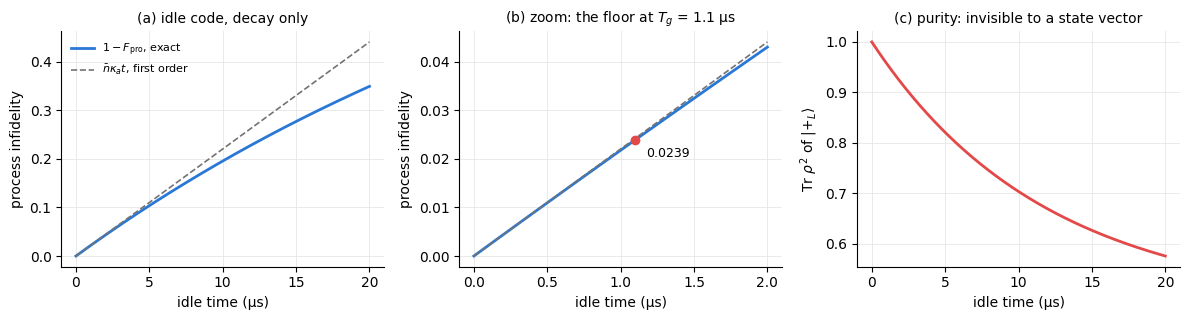

idle floor 1 - F_pro: 1.0 μs 0.0218 (first order 0.0221); 1.1 μs 0.0239


In [7]:
cs7 = [c for _, c in m7.c_ops]
dt_idle = 0.05                                      # us; exact, the generator is constant
P_idle = sla.expm(me.liouvillian(m7.H_d, cs7) * dt_idle)
t_idle = np.arange(0, 401) * dt_idle                # 0 .. 20 us
E, Theta, w = process_targets("I", N_C_DEMO)
plus = (VL7[:, 0] + VL7[:, 1]) / np.sqrt(2)
vecs = [x.reshape(-1, order="F") for x in list(E) + [np.outer(plus, plus.conj())]]
F_idle, purity = [], []
for k in range(t_idle.size):
    if k:
        vecs = [P_idle @ v for v in vecs]
    mats = [v.reshape(m7.d, m7.d, order="F") for v in vecs]
    F_idle.append(process_fidelity_from_outputs(np.stack(mats[:3]), Theta, w))
    purity.append(np.trace(mats[3] @ mats[3]).real)
F_idle, purity = np.array(F_idle), np.array(purity)
T_GATE = 1.1
k_gate = int(round(T_GATE / dt_idle))
IDLE_FLOOR = 1 - F_idle[k_gate]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))
for ax, tmax in zip(axes[:2], (20, 2)):
    sel = t_idle <= tmax + 1e-9
    ax.plot(t_idle[sel], 1 - F_idle[sel], color="#2a78d6", lw=2, label=r"$1 - F_{\rm pro}$, exact")
    ax.plot(t_idle[sel], 3 * dev.kappa_a * t_idle[sel], color="0.45", lw=1.2, ls="--",
            label=r"$\bar n\kappa_a t$, first order")
    ax.set_xlabel("idle time (μs)"); ax.set_ylabel("process infidelity")
    tidy(ax)
axes[0].set_title("(a) idle code, decay only", fontsize=10)
axes[0].legend(frameon=False, fontsize=8)
axes[1].set_title(r"(b) zoom: the floor at $T_g$ = 1.1 μs", fontsize=10)
axes[1].plot([T_GATE], [IDLE_FLOOR], "o", color="#e34948", ms=6)
axes[1].annotate(f"{IDLE_FLOOR:.4f}", (T_GATE, IDLE_FLOOR), textcoords="offset points", xytext=(8, -12), fontsize=9)
ax = axes[2]
ax.plot(t_idle, purity, color="#e34948", lw=2)
ax.set_xlabel("idle time (μs)"); ax.set_ylabel(r"Tr $\rho^2$ of $|{+}_L\rangle$")
ax.set_title("(c) purity: invisible to a state vector", fontsize=10)
tidy(ax)
fig.tight_layout()
fig.savefig("figures/dgrape_idle_density_matrix.png", dpi=150)
plt.show()
print(f"idle floor 1 - F_pro: 1.0 μs {1 - F_idle[20]:.4f} (first order {3 * dev.kappa_a:.4f}); "
      f"1.1 μs {IDLE_FLOOR:.4f}")

**Figure 1.** Idling the code with decay only. (a, b) The process infidelity follows $\bar n\kappa_a t$ for the
first few μs and is about 2.4 % at a 1.1 μs gate length. (c) The purity of $|{+}_L\rangle$ drops as soon as a loss
becomes possible, which a state vector cannot represent.

# 5. Propagating the density matrix

## 5.1 Why $\hat\rho$ and not $|\psi\rangle$

After a photon loss at an unknown time, the system is in a **mixture** of the no-jump branch and the "jumped at
$t$" branches. There are two ways to compute with that:

- **Quantum trajectories** average many stochastic $|\psi\rangle$ runs. They are noisy: precision $\epsilon$ needs
  $\sim 1/\epsilon^2$ runs, and the gradient is noisy too.
- **The density matrix** carries every branch at once. It is deterministic and exact, at a cost of $d^2$ numbers.

GRAPE needs a smooth objective and an exact gradient, so this pipeline propagates $\hat\rho$.

## 5.2 The step map is exact

Controls are constant on each step, so the generator is constant too:
$\mathcal L_k = \mathcal L_d + \sum_j u_{kj}\mathcal L_j$ with $\mathcal L_j\hat\rho = -i[\hat H_{c,j},\hat\rho]$.
The controls enter only through the Hamiltonian, and the dissipators are fixed. The exact solution is

$$
\hat\rho_{k+1} = e^{\mathcal L_k\Delta t}\,\hat\rho_k, \qquad \Phi = e^{\mathcal L_{N-1}\Delta t}\cdots e^{\mathcal L_0\Delta t}.
$$

Unlike an ODE solver, this introduces no time-discretization error for a piecewise-constant pulse. The only
approximation is the evaluation of each exponential, and that is controlled (§5.4).

**Why not diagonalize, as `core/` does?** `core/grape_core.py` exponentiates each Hermitian $\hat H_k$ through an
eigendecomposition. $\mathcal L_k$ is **non-normal**: dissipation makes it neither Hermitian nor anti-Hermitian,
so its eigenvectors are not orthogonal and its eigendecomposition can be ill-conditioned. The exponential's
**action** on $\hat\rho$ is computed instead.

## 5.3 Acting at the matrix level

Stacking the columns of $\hat\rho$ gives $\frac{d}{dt}\mathrm{vec}\,\hat\rho = \mathbf L\,\mathrm{vec}\,\hat\rho$, with a
$d^2\times d^2$ superoperator $\mathbf L$ (`AQEC.master_equation.liouvillian`). It serves only as the §8 reference.
Training never forms it and applies $\mathcal L$ directly to $d\times d$ matrices.

**Effective Hamiltonian.**

$$
\hat H_{\rm eff} = \hat H - \tfrac i2\,\hat C, \qquad \hat C = \sum_\mu \hat c_\mu^\dagger\hat c_\mu .
$$

- $\hat H = \hat H_d + \sum_j u_{kj}\hat H_{c,j}$: the Hermitian Hamiltonian of step $k$ (drift plus drives).
- $\hat c_\mu$: the jump operator of process $\mu$ (Table 6), rate included, e.g. $\sqrt{\kappa_a}\,\hat a$.
- $\hat c_\mu^\dagger\hat c_\mu$: the rate of jump $\mu$ as an operator. Example: $\kappa_a\hat a^\dagger\hat a = \kappa_a\hat n_a$,
  so a state with $n$ photons loses one at rate $n\kappa_a$.
- $\hat C$: the total jump rate. It is diagonal because every $\hat c_\mu$ is monomial (§4), and the code stores it as `Gdiag`.
- $-\tfrac i2\hat C$: an imaginary energy. It makes $\hat H_{\rm eff}$ non-Hermitian, so amplitudes decay as
  $e^{-\hat C t/2}$ as well as rotating.

**Forward generator.**

$$
\mathcal L\hat\rho = -i\big(\hat H_{\rm eff}\hat\rho - \hat\rho\hat H_{\rm eff}^\dagger\big) + \sum_\mu \hat c_\mu\hat\rho\hat c_\mu^\dagger
$$

- $\hat\rho$: the $d\times d$ input (a state, or one of the basis inputs $E_{ij}$ of §3.2).
- $\hat H_{\rm eff}^\dagger = \hat H + \tfrac i2\hat C$: the conjugate transpose, which acts from the right.
- $-i(\hat H_{\rm eff}\hat\rho - \hat\rho\hat H_{\rm eff}^\dagger)$: the no-jump evolution. It rotates $\hat\rho$ and drains
  trace at rate $\mathrm{Tr}(\hat C\hat\rho)$.
- $\hat c_\mu\hat\rho\hat c_\mu^\dagger$: the jumped branch (for $\hat a$, one photon removed). It adds back
  $\mathrm{Tr}(\hat c_\mu^\dagger\hat c_\mu\hat\rho)$, so the total trace is conserved.

This is the §4 GKSL equation, regrouped. Expanding the first term:

$$
-i\big(\hat H_{\rm eff}\hat\rho - \hat\rho\hat H_{\rm eff}^\dagger\big)
= -i\big(\hat H\hat\rho - \tfrac i2\hat C\hat\rho - \hat\rho\hat H - \tfrac i2\hat\rho\hat C\big)
= -i[\hat H,\hat\rho] - \tfrac12\{\hat C,\hat\rho\}.
$$

Subtract this from the §4 form, $\mathcal L\hat\rho = -i[\hat H,\hat\rho] + \sum_\mu\big(\hat c_\mu\hat\rho\hat c_\mu^\dagger - \tfrac12\{\hat c_\mu^\dagger\hat c_\mu,\hat\rho\}\big)$:

$$
\mathcal L\hat\rho + i\big(\hat H_{\rm eff}\hat\rho - \hat\rho\hat H_{\rm eff}^\dagger\big)
= \Big(-i[\hat H,\hat\rho] - \tfrac12\{\hat C,\hat\rho\} + \sum_\mu \hat c_\mu\hat\rho\hat c_\mu^\dagger\Big)
- \Big(-i[\hat H,\hat\rho] - \tfrac12\{\hat C,\hat\rho\}\Big)
= \sum_\mu \hat c_\mu\hat\rho\hat c_\mu^\dagger .
$$

**The anticommutator $-\tfrac12\{\hat c_\mu^\dagger\hat c_\mu,\hat\rho\}$ of every $\mathcal D[\hat c_\mu]$ cancels out.** The
anti-Hermitian part of $\hat H_{\rm eff}$ reproduces it exactly, so the only jump term left is the sandwich.

*Purpose:* `lindblad_np.apply_L` uses this form to propagate the inputs forward, $\hat\rho_k\to\hat\rho_{k+1}$, inside the
Taylor series of §5.4. It costs two $d\times d$ products plus an $O(d^2)$ gather for the monomial sandwiches.

**Adjoint generator.**

$$
\mathcal L^\dagger \hat X = i\big(\hat H_{\rm eff}^\dagger\hat X - \hat X\hat H_{\rm eff}\big) + \sum_\mu \hat c_\mu^\dagger\hat X\hat c_\mu
$$

- $\hat X$: the costate. It is a $d\times d$ matrix that starts as the target $T_{ij}$ (§3.2) at the end of the pulse
  and is propagated backward.
- $\mathcal L^\dagger$: the Hilbert–Schmidt adjoint of $\mathcal L$, defined by
  $\mathrm{Tr}[\hat X^\dagger\,\mathcal L\hat\rho] = \mathrm{Tr}[(\mathcal L^\dagger\hat X)^\dagger\,\hat\rho]$ for all $\hat X, \hat\rho$.
- Compared with $\mathcal L$, the sign flips ($-i\to+i$), $\hat H_{\rm eff}$ and $\hat H_{\rm eff}^\dagger$ swap sides, and the sandwich
  becomes $\hat c_\mu^\dagger\hat X\hat c_\mu$, which is also a monomial gather.
- The same expansion gives $\mathcal L^\dagger\hat X = i[\hat H,\hat X] - \tfrac12\{\hat C,\hat X\} + \sum_\mu\hat c_\mu^\dagger\hat X\hat c_\mu$,
  and the anticommutator again sits inside $\hat H_{\rm eff}$. A useful check: $\mathcal L^\dagger\mathbb 1 = 0$, which is
  trace preservation seen from the adjoint side.

*Purpose:* `lindblad_np.apply_Ldag` uses this form to pull the target backward. Since
$\mathrm{Tr}[T^\dagger\Phi(E)] = \mathrm{Tr}[(\Phi^\dagger T)^\dagger E]$, pairing the forward $\hat\rho_k$ with the backward
$\hat X_k$ at each step gives the gradient with respect to every $u_k$ from one forward and one backward pass (§6).
It costs the same as $\mathcal L$.

The three inputs $E_{00}, E_{11}, E_{01}$ travel together as one `(3, d, d)` stack.

**Table 7.** Cost of one step at $n_c = 12$ ($d = 72$), counting a complex product as $8d^3$ real flops.

| approach | memory | flops per step |
|---|---|---|
| form $\mathbf L_k$ and exponentiate it (Padé) | $d^4 = 2.7\times10^7$ entries | $\sim 8(d^2)^3 \approx 10^{12}$ |
| Taylor **action** on the three $d\times d$ inputs | $3d^2$ per state | $3 \times m \times 2 \times 8d^3 \approx 5\times10^{8}$ ($m = 29$) |

**Spectral shift.** The commutator does not change under $\hat H \to \hat H - c\,\mathbb 1$, so the drift is centred on
the midpoint of its diagonal. This halves $\|\hat H\|$, and with it the norm bound $\beta$ of §5.4. Nothing else changes.

## 5.4 The Taylor series and its truncation

The exponential of §5.2 is replaced by a polynomial in $\mathcal L_k$. Its length is set by a size bound on $\mathcal L_k$
and an error target. Those are the three equations below.

**Taylor polynomial.**

$$
e^{\mathcal L\Delta t}\hat\rho \;\approx\; P_{s,m}(\mathcal L)\,\hat\rho = \Big[\sum_{\ell=0}^{m} \frac{(\tau\mathcal L)^\ell}{\ell!}\Big]^{s}\hat\rho,\qquad \tau = \Delta t/s .
$$

- $\mathcal L = \mathcal L_k$: the generator of step $k$ (§5.3).
- $\Delta t$: the step length, 2 ns.
- $s$: the number of substeps. $\Delta t$ is split into $s$ pieces of length $\tau = \Delta t/s$.
- $m$: the number of Taylor terms per substep.
- $(\tau\mathcal L)^\ell\hat\rho$: $\mathcal L$ applied $\ell$ times. Each term reuses the previous one,
  $\mathrm{term}_\ell = \frac{\tau}{\ell}\,\mathcal L(\mathrm{term}_{\ell-1})$, so it costs one `apply_L` call.
- $[\,\cdot\,]^s$: the substep polynomial applied $s$ times in a row.
- $P_{s,m}$: the resulting polynomial, which stands in for the exponential.

*Purpose:* computes $e^{\mathcal L\Delta t}\hat\rho$ with nothing but `apply_L`: no $d^2\times d^2$ matrix and no
eigendecomposition (§5.2). The cost is $s\cdot m$ calls (`lindblad_np.taylor_action`).

**Finding $m$.** The norm bound and the remainder bound below exist to choose $m$. The norm bound measures how
large one step is. The remainder bound converts that size into the number of Taylor terms needed for $10^{-15}$
accuracy. $s$ is chosen alongside $m$, but **the default is $s = 1$**: it comes out as 1 at every training setting
($n_c = 12, 14, 16$, peak $|\epsilon|$ up to 50 rad/μs). Each 2 ns step is therefore a single series, of $m = 27$–28 terms
at the recipe's cap $|\epsilon| = 25$.

**Norm bound.**

$$
\beta = 2\Big(\tfrac12\,\mathrm{width}(\hat H_d) + 2|\epsilon_C|_{\max}\|\hat a\| + 2|\epsilon_T|_{\max}\|\hat q\|\Big) + 2\sum_\mu\|\hat c_\mu\|^2 .
$$

- $\beta$: an upper bound on $\|\mathcal L_k\|$ that holds on every step of the pulse. Its units are rad/μs, and it is the
  fastest rate at which $\mathcal L_k$ can change $\hat\rho$. ($\|\cdot\|$ is the spectral norm for operators and the
  Frobenius-induced norm for $\mathcal L$.)
- $\mathrm{width}(\hat H_d)$: the largest minus the smallest diagonal entry of the (diagonal) drift. After the §5.3
  centring, $\tfrac12\,\mathrm{width} = \|\hat H_d - c\,\mathbb 1\|$. The width is mostly $\alpha_q \approx 844$ rad/μs.
- $|\epsilon_C|_{\max}, |\epsilon_T|_{\max}$: the pulse's peak drive moduli $|u_I + iu_Q|$ for the cavity and the transmon.
- $2|\epsilon|\,\|\hat a\|$: a bound on the cavity drive $\|\epsilon\hat a + \epsilon^*\hat a^\dagger\|$, with $\|\hat a\| = \sqrt{n_c-1}$.
  The transmon term is the same with $\|\hat q\| = \sqrt2$.
- Outer factor 2: $\|[\hat H,\hat\rho]\| \le 2\|\hat H\|\|\hat\rho\|$, since $\hat H$ acts from both sides.
- $2\|\hat c_\mu\|^2$: a bound on $\mathcal D[\hat c_\mu]$. The sandwich contributes at most $\|\hat c_\mu\|^2$, and so does the
  anticommutator.

*Purpose:* $\beta$ is a speed limit: the fastest rate at which $\mathcal L_k$ could change $\hat\rho$ on any step of the
pulse. It tells the optimizer the upper bound of how big a step is, so that the
remainder bound can pick $m$. At $n_c = 12$ and $|\epsilon| = 25$, width 987, drive 473 and dissipation 7.6 give $\beta = 1467$ rad/μs, so one step has
size $\beta\Delta t = 2.93$.

**Remainder bound.**

$$
\frac{\theta^{m+1}}{(m+1)!}\,e^{\theta} \le 10^{-15}, \qquad \theta = \beta\tau .
$$

- $\theta$: a bound on $\|\tau\mathcal L_k\|$, the dimensionless size of one substep.
- $\theta^{m+1}/(m+1)!$: the bound on the first neglected Taylor term.
- $e^{\theta}$: covers the sum of all the further neglected terms.
- $10^{-15}$: the tolerance (`TAYLOR_TOL`), about double-precision round-off.

*Purpose:* turns the step size $\theta$ into a number of terms. It works like $e^x$: the larger $x$, the more terms are
needed. The left-hand side is the worst case for everything the series leaves out, and `taylor_spec` picks the smallest
$m$ that keeps it below $10^{-15}$. Too few terms give a wrong fidelity and gradient. Too many waste time, since the
cost is $\propto m$. At $\theta = 2.93$, $m = 27$ passes ($7.6\times10^{-16}$) and $m = 26$ fails ($7.3\times10^{-15}$). The
default is $s = 1$ because two substeps would still need $m = 20$ each, which is 40 calls against 27.

**Consequences.** The errors add, at most once per substep, so over a pulse the truncation error is of order
$Ns\times10^{-15} \approx 10^{-12}$ at $N = 550$: far below anything optimized. Both gradient methods differentiate this
same polynomial $P_{s,m}$, not the exponential, so they agree to round-off rather than merely to the tolerance.
$(s, m)$ is recomputed from each pulse's peak amplitude (`spec_for_pulse`).

In [8]:
rows = []
for nc in (7, 10, 12, 14):
    mdl = Model(nc)
    for eps in (0.0, 15.0, 25.0):
        s, m = lnp.taylor_spec(mdl.generator_norm_bound(eps, eps) * DT)
        rows.append({"n_c": nc, "peak |ε| (rad/μs)": f"{eps:g}",
                     "beta*dt": mdl.generator_norm_bound(eps, eps) * DT, "(s, m)": f"({s}, {m})"})
spec_table = pd.DataFrame(rows).pivot(index="n_c", columns="peak |ε| (rad/μs)", values="(s, m)")
display(spec_table.style.set_caption("Table 7b. Taylor (s, m) at dt = 2 ns, by truncation and peak drive modulus"))

peak |ε| (rad/μs),0,15,25
n_c,,,
7,"(1, 22)","(1, 24)","(1, 26)"
10,"(1, 23)","(1, 25)","(1, 27)"
12,"(1, 23)","(1, 26)","(1, 27)"
14,"(1, 23)","(1, 26)","(1, 28)"


**How the table is computed.** Each entry is $(s, m)$ = `taylor_spec`$(\theta)$, with $\theta = \beta\,\Delta t$ and
$\Delta t = 2$ ns. $\beta$ is the §5.4 norm bound on `Model(n_c)` ($n_r = 2$, decay only, no higher-order terms), with
**both** peak moduli set to the column value: $|\epsilon_C|_{\max} = |\epsilon_T|_{\max} = |\epsilon|$
(`generator_norm_bound(eps, eps)`). No pulse is propagated, because $\beta$ needs only the two peaks. Equal peaks are
the worst case for a pulse at the recipe cap, since `amp_max` = 25 caps each drive's modulus separately. A real pulse
with a lower transmon peak gets the same or a smaller $m$.

**Why it depends on $n_c$.** $\beta$ must cover the highest Fock state kept, $|n_c-1\rangle$, and three of its terms grow
with it:

- drift width $= \alpha_q + (n_c-1)\chi_{gf}$, since the dispersive shift grows with photon number: 987, 1013, 1039 rad/μs
  at $n_c = 12, 14, 16$;
- cavity drive $4\|\hat a\|\,|\epsilon_C|_{\max}$, with $\|\hat a\| = \sqrt{n_c-1}$: 3.32, 3.61, 3.87;
- storage decay $2\kappa_a(n_c-1)$, which is negligible.

The transmon drive ($\|\hat q\| = \sqrt2$) and the other dissipators do not depend on $n_c$. The bound must hold for any
input, including the costate and leaked population, so the top level counts even if the gate never fills it. The
effect on $m$ is small: 27 to 28 between $n_c = 12$ and 14. The real cost of a larger $n_c$ is the matrix size, $\propto(6n_c)^3$.

At the cap $|\epsilon| = 25$ rad/μs, $m = 27$ at $n_c = 12$ and $m = 28$ at $n_c = 14$. $n_c = 16$, not shown, also gives 28.
The random test pulses of §8–§9 have larger peaks (about 50 rad/μs), hence their $m = 29$–32.

# 6. The exact gradient

**Why the adjoint method.** L-BFGS-B needs $F$ and $\partial F/\partial u_{kj}$ for every control: $4N \approx 2200$
numbers at $N = 550$. Finite differences would cost $4N + 1$ propagations per iteration. The adjoint method
(backpropagation, with time steps as layers) gets all of them for about three.

| subsection | goal |
|---|---|
| 6.1 | reduce all $4N$ derivatives to the derivative of one step |
| 6.2 | take that one-step derivative fast: the W matrix (training default) |
| 6.3 | take it independently: the augmented generator (reference) |
| 6.4 | take it automatically: JAX autodiff (cross-check) |

All three differentiate the same polynomial $P_{s,m}$, so they agree to about $10^{-13}$
(`tables/dgrape_gradient_benchmark.csv`).

**The objective, written for differentiation.**

$$
F = \sum_b \Big\langle \tfrac{w_b}{4}\Theta_b,\ \hat\rho_b(N)\Big\rangle, \qquad \langle X, Y\rangle = \mathrm{Re}\,\mathrm{Tr}[X^\dagger Y].
$$

- $F$: the process fidelity $F_{\rm pro}$ (§3.2) at one truncation.
- $b \in \{00, 11, 01\}$: the three test inputs $E_b$, with weights $w_b = (1, 1, 2)$.
- $\Theta_b = UE_bU^\dagger$: the target output.
- $\hat\rho_b(k)$: input $b$ after $k$ steps, with $\hat\rho_b(0) = E_b$ and $\hat\rho_b(N) = \Phi(E_b)$.
- $\Phi = P_{N-1}\cdots P_0$, where $P_k = P_{s,m}(\mathcal L_k)$ is the step polynomial of §5.4.
- $\langle X, Y\rangle$: a dot product for matrices. Multiply matching entries, add them up, and keep the real part.

$F$ is **linear** in the final states. That is what makes the adjoint method work.

## 6.1 Adjoint (costate) propagation

**Goal:** reduce all $4N$ derivatives to the derivative of one step.

$$
\Lambda_b(N) = \frac{w_b}{4}\,\Theta_b, \qquad \Lambda_b(k) = P_{s,m}(\mathcal L_k^\dagger)\,\Lambda_b(k+1).
$$

- $\Lambda_b(k)$: the **costate**, a $d\times d$ matrix. It is the sensitivity of $F$ to the state at step $k$:
  $\delta F = \langle\Lambda_b(k), \delta\hat\rho_b(k)\rangle$.
- $\Lambda_b(N)$: read off directly, because $F$ is linear in $\hat\rho_b(N)$ with coefficient $\tfrac{w_b}{4}\Theta_b$.
- $P_{s,m}(\mathcal L_k^\dagger)$: the same step polynomial with $\mathcal L \to \mathcal L^\dagger$ (§5.3, `apply_Ldag`). Its coefficients
  are real, so it is the adjoint of $P_k$.
- *Purpose:* carries the sensitivity backward through the pulse, one step at a time.

The pairing is therefore the same at every step,
$\langle\Lambda_b(k), \hat\rho_b(k)\rangle = \langle\Lambda_b(k+1), P_k\hat\rho_b(k)\rangle$, so
$\sum_b\langle\Lambda_b(k), \hat\rho_b(k)\rangle = F$ for every $k$. $\hat\rho_b(k)$ depends only on earlier controls
and $\Lambda_b(k+1)$ only on later ones. Only $P_k$ depends on $u_{kj}$, the control $j$ (cavity I/Q, transmon I/Q)
on step $k$:

$$
\frac{\partial F}{\partial u_{kj}} = \sum_b\Big\langle \Lambda_b(k+1),\ \frac{\partial P_k}{\partial u_{kj}}\,\hat\rho_b(k)\Big\rangle .
$$

One forward sweep (storing $\hat\rho_b(k)$) and one backward sweep give all $4N$ derivatives. What remains is
$\partial P_k/\partial u_{kj}$, and two exact constructions follow.

## 6.2 The W-matrix form (default, `lindblad_np.fidelity_and_grad`)

**Goal:** the derivative of one step for all four controls at once. It is exact for the Taylor polynomial and costs
about three forward passes.

**Variables.** These are for one substep. Training has $s = 1$, so one substep is the whole step.

- $x = \hat\rho_b(k)$: the step's input. $\Lambda = \Lambda_b(k+1)$: the costate at its output.
- $c_\ell = \tau^\ell/\ell!$: the Taylor coefficients, so $P = \sum_\ell c_\ell\mathcal L^\ell$.
- $a_q = \mathcal L^q x$: the **forward terms**, i.e. the input hit by $\mathcal L$ $q$ times.
- $b_p = (\mathcal L^\dagger)^p\Lambda$: the **costate terms**.
- $\mathcal L_j\hat\rho = -i[\hat H_{c,j}, \hat\rho]$: how $\mathcal L_k$ changes with $u_{kj}$. The $\hat H_{c,j}$ are $\hat a + \hat a^\dagger$,
  $i(\hat a - \hat a^\dagger)$, $\hat q + \hat q^\dagger$ and $i(\hat q - \hat q^\dagger)$.
- $\tilde B_q = \sum_p c_{p+q+1}\,b_p$: all the costate terms that pair with $a_q$, combined with their coefficients.
- $W_k$: one $d\times d$ matrix per step that collects everything the gradient needs.

**How it works.**

1. **Product rule.** $\mathcal L^\ell$ is $\ell$ copies of $\mathcal L$. Nudging $u_j$ turns one copy at a time into $\mathcal L_j$,
   so the derivative is a sum of $\ell$ terms, with $\mathcal L_j$ in each position. It is *not* $\ell\,\mathcal L^{\ell-1}\mathcal L_j$,
   because $\mathcal L$ and $\mathcal L_j$ do not commute. That is why the exact gradient takes work.
2. **Split each term at $\mathcal L_j$.** The copies to the right of $\mathcal L_j$ act on the input and form a forward term $a_q$.
   The copies to the left move onto the costate, by the adjoint, and form a costate term $b_p$. Each term becomes
   "costate term, $\mathcal L_j$, forward term".
3. **Group by forward term.** Each $a_q$ pairs with several $b_p$. Adding those up gives $\tilde B_q$, which turns a
   double sum into $m$ pairings.
4. **Pull out the control.** $\mathcal L_j$ is a commutator with $\hat H_{c,j}$, and the trace is cyclic, so $\hat H_{c,j}$ moves to
   the front. What is left does not depend on $j$:

$$
\frac{\partial F}{\partial u_{kj}} = \mathrm{Re}\,\mathrm{Tr}\big[\hat H_{c,j}\,W_k\big], \qquad
W_k = -i\sum_b\sum_{q=0}^{m-1}\big(a_q\tilde B_q^\dagger - \tilde B_q^\dagger a_q\big).
$$

With several substeps, $W_k$ also sums over them, last to first.

**Why it is cheap.**

- One $W_k$ serves all four controls. Each derivative is then just a trace.
- The $b_p$ are needed anyway, because the costate moves back as $\Lambda_b(k) = \sum_\ell c_\ell b_\ell$. They come for free.
- The sums over $q$ and $b$ are two single matrix products (`_w_term`).
- The $a_q$ are recomputed in the backward sweep instead of being stored, which saves a factor $m$ in memory.

The total cost is about **three forward passes**: the stored forward sweep, recomputing the $a_q$, and the costate terms.

## 6.3 The augmented-generator form (reference, `fidelity_and_grad_augmented`)

**Goal:** an independent derivation of the same derivative, to check §6.2.

$$
\frac{d}{dt}\begin{pmatrix} x \\ y_j\end{pmatrix} = \begin{pmatrix}\mathcal L & 0 \\ \mathcal L_j & \mathcal L\end{pmatrix}\begin{pmatrix} x \\ y_j\end{pmatrix},
\qquad \text{starting from } (\hat\rho_k,\ 0).
$$

- $x$: the state, $\dot x = \mathcal L x$.
- $y_j$: its derivative with respect to $u_j$. The equation $\dot y_j = \mathcal L y_j + \mathcal L_j x$ is $\dot x = \mathcal L x$ differentiated.

The lower-left block of the $\ell$-th power of this matrix is $\sum_p\mathcal L^p\mathcal L_j\mathcal L^{\ell-1-p}$, which is
exactly the derivative of $\mathcal L^\ell$. Run through the same Taylor polynomial, $y_j$ ends as
$\frac{\partial P}{\partial u_j}\hat\rho_k$, and $\partial F/\partial u_{kj} = \sum_b\langle\Lambda_b(k+1), y_{j,b}\rangle$. This is the
matrix-action version of Van Loan's block-exponential trick. It carries five blocks ($x$ and $y_0,\dots,y_3$) through
every Taylor term, about **seven forward passes**, and is kept as an independent check, not for speed.

## 6.4 JAX autodiff (`DGRAPE/lindblad_jax.py`)

**Goal:** a third gradient with no hand derivation.

The same polynomial is written in `jax.numpy` and differentiated with `jax.value_and_grad`. Reverse-mode autodiff of
a polynomial *is* an adjoint method, so it computes the same numbers. That makes it the natural cross-check and the
quickest way to add a new cost term. Implementation:

- double precision;
- steps in `lax.scan` under `jit`, with $(s, m)$ static, so a new pair recompiles;
- `jax.checkpoint` on the step body. Without it, reverse mode would store every Taylor term of every step:
  $Nm\cdot 3d^2$ complex numbers, about 3.6 GB at $n_c = 12$, $N = 500$, $m = 29$. With it, only the $\hat\rho_b(k)$ are
  stored, and each step's terms are recomputed on the way back, as §6.2 does by hand.

**These are not the first-order gradient** $\partial F/\partial u_{kj} \approx \Delta t\,\langle\Lambda,
\mathcal L_j\hat\rho\rangle$ of standard GRAPE and of Chen's method. That approximation keeps only the $\ell = 1$ term and
needs $\|\mathcal L\|\Delta t \ll 1$. Here $\|\mathcal L\|\Delta t \approx 2$–3, the $\theta$ of §5.4.

# 7. The training cost

The closed-system production pulses (`experiments.ipynb` §1; `core/optimizer.optimize_multi_state_pulse`) are
trained on more than a fidelity: smoothness, amplitude and bandwidth limits, and a check against the truncation.
DGRAPE uses the same construction with one change: the closed-system fidelity becomes the Lindblad $F_{\rm pro}$.
Implementation: `DGRAPE/objective.py` (cost), `DGRAPE/train.py` (driver), `DGRAPE/recipe.py` (defaults).

## 7.1 The cost

$$
\text{cost}(x) = 1 - \bar F_{\rm pro}(u)
+ \lambda_{\text{disc}}\!\!\sum_{i\neq j}(F_i-F_j)^2
+ \lambda_{\text{deriv}}\sum_k \|u_k-u_{k-1}\|^2
+ \lambda_{\text{amp}}\sum_k\sum_{D\in\{C,T\}} \max\!\big(|\epsilon_D(k)|-u_{\max},0\big)^2
+ \frac{\lambda_{\text{forbid}}}{M}\sum_i C_i ,
\qquad u = R\,P(x).
$$

- **Fidelity (Heeres Eq. 23).** $\bar F_{\rm pro} = \frac1M\sum_i F_i$, averaged over $M$ training truncations
  $n_c^{(i)}$. Each $F_i$ is the exact open-system process fidelity with its exact gradient (§6). This is the only
  term that depends on the backend: `backend="np"` (W form) or `"jax"`.
- **Discrepancy (Heeres Eq. 24).** This penalizes the truncations for *disagreeing*. A pulse that drives population
  to the top of the truncated Fock space behaves differently at different $n_c$, so this term catches it. It reuses
  the per-truncation values and gradients already computed, at no extra propagation cost. The sum runs over ordered
  pairs, as in `core/optimizer.py`.
- **Derivative.** $\lambda_{\text{deriv}}\sum_k\|u_k-u_{k-1}\|^2$ discourages waveforms the arbitrary waveform
  generator cannot follow (`core.grape_core.derivative_penalty`).
- **Amplitude (Heeres Supp. Eq. 19).** A soft cap on the drive modulus $|\epsilon_C|$, $|\epsilon_T|$
  (`amp_norm="modulus"`).
- **Forbidden states (Heeres Supp., "cost for occupation of certain higher states").** Heeres write it as
  $C = \sum_n |\langle\psi_F|\psi_n\rangle|^2$ summed over time steps. For density matrices it becomes
  $C_i = \sum_{k=1}^{N}\sum_{b\in\{0_L,1_L\}}\mathrm{Tr}[\hat P_F\,\hat\rho_b(k)]$, with
  $\hat P_F = \sum_{n\ge 10}|n\rangle\langle n|\otimes\hat 1_q\otimes\hat 1_r$ the projector onto storage Fock $\ge 10$
  (`forbid_fock_min`). $\hat\rho_b$ are the propagated code basis states $E_{00}$, $E_{11}$. Eq. 24 notices the
  truncation wall only once the truncations disagree, but this term penalizes climbing toward it directly. $C_i$ is
  linear in every $\hat\rho_b(k)$, so its exact gradient comes from the same backward pass as $F_i$. Its costate
  obeys the adjoint recursion of §6 plus a source $\hat P_F$ at every step, and is carried as two extra entries of
  the costate stack (`lindblad_np.fidelity_and_grad(..., forbid_mask=...)`). On a truncation with $n_c \le 10$,
  $\hat P_F = 0$ and the term is exactly zero, so `train.py` refuses such a training list.

The $M$ truncations are independent, so they run as parallel joblib jobs (`n_jobs`, default 3, as `main.py`).

## 7.2 The constraints, which are not cost terms

- **Pre-image and band filter (Heeres Supp. Eq. 22).** L-BFGS-B moves a raw variable $x$, the *pre-image*. The
  physical pulse is its orthogonal projection $P(x)$ onto the allowed frequency bands of $\epsilon_C$ and
  $\epsilon_T$ (`core.fourier_cutoff.project_bandlimit`). Every $x$ therefore gives a band-limited pulse.
- **Ramp.** After the projection, the pulse is multiplied by an envelope $R = \mathrm{diag}(\mathrm{env})$ that
  rises and falls as a 48 ns Gaussian (`core.ramp`). The Gaussian's tail value is subtracted so the envelope reaches
  zero at the ends. The drive therefore starts and ends near zero by construction, not by penalty. Both $P$ and $R$
  are self-adjoint, so the gradient chain is $\partial\text{cost}/\partial x = P(\mathrm{env}\odot\partial\text{cost}/\partial u)$.
- **Box.** L-BFGS-B bounds each entry, $|x| \le$ `hard_amp_limit`. Without it the optimizer inflates $x$ near the
  ramped edges to buy back control authority. Entries pinned at the bound mean the pulse was clipped rather than
  converged, so the run report counts them. A starting point outside the box is refused rather than silently clipped.

`DGRAPE/train.py` also reproduces core's run logic:

- **Start:** a smooth seeded cold start, random amplitudes in the lowest 4 % of the frequency bins (up to about
  10 MHz at 2 ns) scaled to a peak of 4 rad/μs. Alternatively, an exact resume from a saved pre-image (`init_x`).
- **Best-vs-final:** the returned $(u, x)$ pair is the better of the final point and the best $\bar F$ seen.
- **Run report:** per-truncation $F_{\rm pro}$ and $F_{\rm avg}$, the drive modulus against $u_{\max}$, the
  pre-image peak and the pinned fraction, plus `core.ramp.constraint_report` (endpoint amplitude, out-of-band energy).

## 7.3 The recipe and what carries over to this chip

**Table 8.** DGRAPE defaults (`DGRAPE/recipe.py`), copied from the Heeres-chip production recipe
(`experiments.ipynb` `OPTIMIZATION_RECIPE`, `main.py`). `validation/test_dgrape.py` pins them to
`main.build_arg_parser()`.

| setting | value | origin | on the Shirol chip |
|---|:-:|---|---|
| cavity band | $\pm27$ MHz | Heeres recipe | far above the storage dynamics needed (displacements, $n\chi$-selective phases) |
| transmon band | $\pm33$ MHz | Heeres recipe | keeps every number-split $g\to e$ line ($n\chi_{ge}/2\pi \le 5.6$ MHz for $n \le 5$); **removes the $e\to f$ line at $\alpha_q/2\pi = 134$ MHz**, so the filter itself blocks resonant leakage to $\lvert f\rangle$ |
| ramp | 48 ns per side | Heeres recipe | 96 ns of a 1.1 μs pulse (8.7 %) |
| $\lambda_{\text{deriv}}$ | $10^{-5}$ | Heeres penalty sweep | unvalidated here |
| $\lambda_{\text{amp}}$, $u_{\max}$ | $8\times10^{-5}$, 25 rad/μs | Heeres recipe | Shirol publish no drive limit. 25 rad/μs is a transmon Rabi rate $2u_{\max}/2\pi \approx 8$ MHz, far below $\alpha_q/2\pi$ |
| $\lambda_{\text{disc}}$ | 0.5 | Heeres recipe | needs $\ge 2$ truncations |
| `hard_amp_limit` | 25 | Heeres recipe | binds on the Heeres chip for amplitude-hungry gates; check per run |
| training truncations | $[12, 14, 16]$ | **not** Heeres (`main.py` uses $[22, 24, 26]$) | the code needs only Fock 5, and the cost grows as $(6n_c)^3$. $[10, 12]$ failed (§10); every entry must exceed the forbidden threshold. To be checked on a held-out $n_c$ |
| $\lambda_{\rm forbid}$, threshold | $10^{-3}$, Fock $\ge 10$ | DGRAPE only (Heeres Supp., forbidden states) | raw sum over steps: 1 % forbidden population held for 550 steps costs about 0.01. Rescale if $N$ changes a lot |
| `n_jobs` | 3 | `main.py --n-jobs` | one joblib job per truncation; results do not depend on it (tested) |
| higher-order terms (§2.4) | off by default | Eq. (2) as printed | **on** for training here (`--higher-order`) |
| gate duration, $\Delta t$ | required arguments | — | chip-dependent; §10 uses 1.1 μs, 2 ns |

Every weight is inherited, so every weight is a *default to validate*, not a result.

The cell builds the recipe objective for a 1.1 μs pulse and reports what the constraint chain does to the actual cold
start and to a white-noise pre-image.

In [9]:
from core.ramp import constraint_report
from DGRAPE.objective import OpenGrapeObjective
from DGRAPE.recipe import RECIPE
from DGRAPE.train import initial_preimage

N_REC = int(round(T_GATE / DT))                     # 550 steps
obj = OpenGrapeObjective("X", N_REC, DT, include_higher_order=True)
UNIT = {"cav_band": " MHz", "tra_band": " MHz", "ramp_ns": " ns"}
for k, v in obj.config().items():
    if k == "penalties":
        v = {**v, "amp_max": f"{v['amp_max']} rad/μs"}
    print(f"  {k:10s} {v}{UNIT.get(k, '')}")

x_cold, _, _ = initial_preimage(obj, seed=42)
x_white = np.random.default_rng(0).normal(0, 10, (N_REC, 4))
for label, x_ in [("cold start", x_cold), ("white-noise pre-image", x_white)]:
    c = constraint_report(obj.to_physical(x_), DT, obj.cav_band, obj.tra_band)
    print(f"\n{label}: peak |eps| cav {c['peak_modulus_cav']:.2f}, tra {c['peak_modulus_tra']:.2f} rad/μs; "
          f"endpoints {c['endpoint_rel_to_peak']:.2%} of peak; out-of-band energy "
          f"cav {c['out_of_band_cavity']:.1e}, tra {c['out_of_band_transmon']:.1e}")

  trunc_list [12, 14, 16]
  cav_band   (-27.0, 27.0) MHz
  tra_band   (-33.0, 33.0) MHz
  ramp_ns    48.0 ns
  penalties  {'deriv': 1e-05, 'amp': 8e-05, 'amp_max': '25.0 rad/μs', 'disc': 0.5, 'forbid': 0.001}
  amp_norm   modulus
  backend    np
  forbid_fock_min 10
  n_jobs     3
  c_ops      ['a', 'r', 's_ge', 's_ef']

cold start: peak |eps| cav 4.05, tra 4.28 rad/μs; endpoints 0.65% of peak; out-of-band energy cav 1.0e-05, tra 1.0e-05

white-noise pre-image: peak |eps| cav 12.15, tra 12.77 rad/μs; endpoints 0.68% of peak; out-of-band energy cav 2.2e-03, tra 1.3e-03


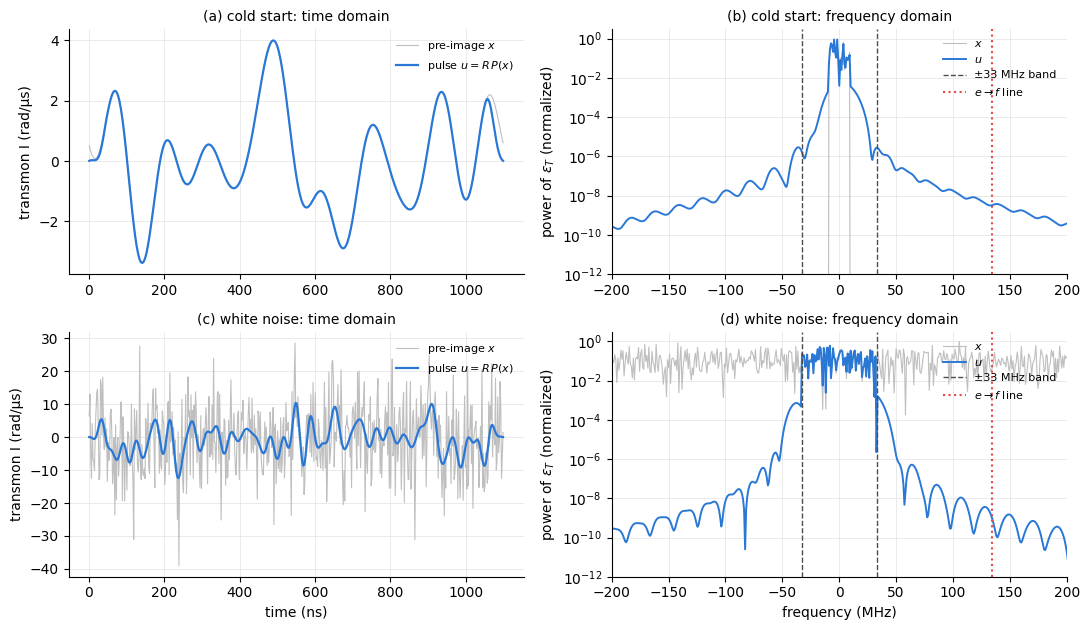

In [10]:
t_ns = (np.arange(N_REC) + 0.5) * DT * 1e3
freq = np.fft.fftshift(np.fft.fftfreq(N_REC, d=DT))            # MHz


def power(i_col, q_col):
    # spectrum of eps = I - iQ (Sec. 2.2); numpy's e^{+i2pi f t} convention puts the
    # g->e lines at +n chi_ge/2pi and the e->f line at +alpha_q/2pi
    return np.abs(np.fft.fftshift(np.fft.fft(i_col - 1j * q_col))) ** 2


fig, axes = plt.subplots(2, 2, figsize=(11, 6.4))
for row, (label, x_) in enumerate([("cold start", x_cold), ("white noise", x_white)]):
    u_ = obj.to_physical(x_)
    ax = axes[row, 0]
    ax.plot(t_ns, x_[:, 2], color="0.75", lw=0.8, label=r"pre-image $x$")
    ax.plot(t_ns, u_[:, 2], color="#2a78d6", lw=1.6, label=r"pulse $u = R\,P(x)$")
    ax.set_ylabel("transmon I (rad/μs)")
    ax.set_title(f"({'ac'[row]}) {label}: time domain", fontsize=10)
    ax.legend(frameon=False, fontsize=8, loc="upper right")
    tidy(ax)
    ax = axes[row, 1]
    sx, su = power(x_[:, 2], x_[:, 3]), power(u_[:, 2], u_[:, 3])
    ax.semilogy(freq, sx / sx.max(), color="0.75", lw=0.8, label=r"$x$")
    ax.semilogy(freq, np.maximum(su / sx.max(), 1e-14), color="#2a78d6", lw=1.4, label=r"$u$")
    for i_e, edge in enumerate(RECIPE["tra_band"]):
        ax.axvline(edge, color="0.3", ls="--", lw=1, label="±33 MHz band" if i_e == 0 else None)
    ax.axvline(dev.alpha_q / TWO_PI, color="#e34948", ls=":", lw=1.5, label=r"$e\to f$ line")
    ax.set_xlim(-200, 200); ax.set_ylim(1e-12, 3)
    ax.set_ylabel(r"power of $\epsilon_T$ (normalized)")
    ax.set_title(f"({'bd'[row]}) {label}: frequency domain", fontsize=10)
    ax.legend(frameon=False, fontsize=8, loc="upper right")
    tidy(ax)
axes[1, 0].set_xlabel("time (ns)"); axes[1, 1].set_xlabel("frequency (MHz)")
fig.tight_layout()
fig.savefig("figures/dgrape_constraint_chain.png", dpi=150)
plt.show()

**Figure 2.** The constraint chain $u = R\,P(x)$ on the transmon drive. Gray: the pre-image $x$ that L-BFGS-B
moves. Blue: the physical pulse $u$. Left: transmon I against time. Right: power of $\epsilon_T = I - iQ$, normalized
to the peak of $x$; dashed lines mark the $\pm33$ MHz band, the red dotted line the $e\to f$ line at $\alpha_q/2\pi$.
(a, b) The seed-42 cold start. (c, d) A white-noise pre-image ($\sigma = 10$ rad/μs), a stand-in for the worst $x$
the optimizer could reach. The panels are read one by one below.

**The two maps.** The physics never sees $x$, only $u = R\,P(x)$:

- $P$: orthogonal projection onto the allowed bands, $\pm27$ MHz (cavity) and $\pm33$ MHz (transmon). It deletes every
  Fourier component outside the band.
- $R = \mathrm{diag}(\mathrm{env})$: the ramp, a 48 ns Gaussian rise and fall that pulls both ends of the pulse to zero.

The band limit and the zero endpoints therefore hold for *every* $x$, by construction rather than by penalty.

**Panel by panel.**

- **(a)** Gray and blue coincide except at the ends. The cold start uses only the lowest ~4 % of frequencies
  (≲ 10 MHz), so it is already in band and $P$ does nothing; the gap at the ends (e.g. $x \approx 2$ near 1070 ns,
  $u \to 0$) is $R$. The peak, ~4 rad/μs against $u_{\max} = 25$, is deliberately gentle.
- **(b)** $x$ occupies only ±10 MHz. $u$ keeps that core but grows tails across the band edges at ~$10^{-6}$:
  multiplying by the envelope in time is a convolution in frequency. Out-of-band energy is $10^{-5}$ (cell above).
- **(c)** The filter discards most of the noise. The band holds 66 of the 500 MHz Nyquist range (13 % of the bins),
  so the RMS should fall by $\sqrt{0.13}\approx 0.36$: 10.2 → 3.8 rad/μs measured mid-pulse.
- **(d)** Flat in band, down by many decades outside. At the $e\to f$ line $u$ sits near $10^{-8}$–$10^{-9}$: the
  filter blocks resonant leakage to $|f\rangle$, so no pulse can learn it, while every number-split $g\to e$ line
  ($\le 5.6$ MHz for $n \le 5$) stays in band. The $10^{-3}$–$10^{-4}$ skirts just outside $\pm33$ MHz are the ramp
  again, higher than in (b) because here $x$ is at full strength right up to the band edge. This is the price of
  applying $R$ after $P$ (out-of-band energy $2.2\times10^{-3}$ cavity, $1.3\times10^{-3}$ transmon); the reverse
  order would keep the band exact but leave the ends non-zero.

**Consequence for the optimizer.** $P$ and $R$ are self-adjoint, so
$\partial\,\text{cost}/\partial x = P(\mathrm{env}\odot\partial\,\text{cost}/\partial u)$ has no out-of-band
component. The out-of-band part of $x$ (87 % of it in (c)) is invisible to the cost and never changes. $x$ and $u$ can
look very different; only $u$ is physical, which is why the run report checks both.

# 8. Validation

Each check compares the pipeline with something independent of it: a different algorithm, a physical law or a
different solver. The results collect into Table 9 (§8.6). The full suite, `python3 validation/test_dgrape.py -v`, has
29 tests and runs in about 3 min.

**Common setup.**

- $n_c = 7$ ($d = 42$): the smallest truncation that holds the code, so the brute-force references stay affordable.
- **Random test pulses and $\sigma$.** Each check drives the system with a made-up pulse,
  `u = rng.normal(0, σ, (N, 4))`. That is $N$ steps × 4 controls, each value drawn from a Gaussian with standard
  deviation $\sigma$ (rad/μs). **$\sigma$ is the pulse strength.** For scale, a drive modulus $|u_I + iu_Q|$ is typically
  about $1.25\sigma$, and the training cap is $u_{\max} = 25$ rad/μs. Strong pulses ($\sigma = 15$) stress the
  propagator. Gentle ones ($\sigma = 3$) keep gradients clean.
- **Channels.** Most checks turn on every dissipation channel, dephasing and heating included, so the opt-in channels
  are tested too.

## 8.1 Step map against the full superoperator exponential

**Purpose:** check that the fast Taylor step (§5.3–5.4) computes the exact one-step evolution
$e^{\mathcal L_k\Delta t}\hat\rho$. The reference is the textbook route that training avoids: build the full
$1764\times1764$ Liouvillian and exponentiate it with `scipy.linalg.expm`, a different algorithm. The pulse has 12 steps
(24 ns) at $\sigma = 15$. It runs once with decay only and once with every channel on.

In [11]:
def superop_propagate(model, u, R0, dt):
    cs = [c for _, c in model.c_ops]
    vs = [R.reshape(-1, order="F") for R in R0]
    for k in range(u.shape[0]):
        H = model.H_d + np.tensordot(u[k], model.Hc, axes=1)
        Pk = sla.expm(me.liouvillian(H, cs) * dt)
        vs = [Pk @ v for v in vs]
    return np.stack([v.reshape(model.d, model.d, order="F") for v in vs])


rng = np.random.default_rng(1)
u12 = rng.normal(0, 15, (12, 4))
E, Theta, w = process_targets("H", N_C_DEMO)
for label, kw in [("decay only", dict()), ("all channels", dict(dephasing=True, heating=True))]:
    mdl = Model(N_C_DEMO, **kw)
    taylor = lnp.spec_for_pulse(mdl, u12, DT)
    err = np.abs(lnp.propagate(mdl, u12, E, DT, taylor) - superop_propagate(mdl, u12, E, DT)).max()
    print(f"{label:13s}: Taylor (s, m) = {taylor},  max |Taylor - expm| = {err:.1e}")
    CHECKS.append(("step map vs expm, " + label, "max |difference|", err, 1e-12))

decay only   : Taylor (s, m) = (1, 29),  max |Taylor - expm| = 9.2e-16


all channels : Taylor (s, m) = (1, 29),  max |Taylor - expm| = 1.0e-15


**What the code does.** `superop_propagate` turns each $\hat\rho$ into a vector, builds the full Liouvillian at every
step and multiplies by its `expm`. `lnp.propagate` runs the same 12 steps with the Taylor action. Both act on the
three process inputs of the H gate. The largest entry-wise difference between the final states is printed.

**Results.**

- $(s, m) = (1, 29)$: one substep of 29 terms. That is more than the 27 at the training cap, because this pulse peaks
  near 50 rad/μs.
- Difference $\approx 10^{-15}$, machine precision. The Taylor step is as exact as `expm`.
- The reference uses the uncentred drift and the Taylor path the centred one (§5.3). So this also confirms that the
  spectral shift changes nothing.

## 8.2 Physics checks: positivity, adjoint, closed limit, readout

These are four properties the propagator must have, however it is implemented.

- **CPTP** (completely positive, trace preserving). Any physical evolution must output a valid density matrix: trace
  1, Hermitian, and no negative eigenvalues (no negative probabilities). The exact exponential guarantees this; a
  truncated Taylor series does not. This checks that the truncation is too small to break it. Random mixed state,
  60 steps, $\sigma = 15$, every channel on.
- **Adjoint.** The gradient's backward pass (§6.1) needs $\mathcal L^\dagger$ to be the true adjoint:
  $\langle X, \mathcal L Y\rangle = \langle\mathcal L^\dagger X, Y\rangle$ for any matrices $X$, $Y$. A sign error here would corrupt every
  gradient.
- **Closed limit.** With every decay rate set to 0, the Lindblad machinery must reduce to ordinary Schrödinger
  evolution. $F_{\rm pro}$ must then equal the unitary formula $|\mathrm{Tr}(U^\dagger V_L^\dagger VV_L)|^2/4$ (§3.2). All six gates,
  $\sigma = 8$.
- **Readout.** The readout resonator has photon number $m$, and $n_r$ is how many of its levels are kept. $n_r = 2$ keeps
  $m = 0, 1$. $n_r = 1$ keeps only $m = 0$, which is the same as leaving the readout out. Nothing drives the readout,
  so with decay only it should never leave $m = 0$, and $n_r = 2$ must give the same $F_{\rm pro}$ as $n_r = 1$.
  $\sigma = 15$.

In [12]:
mall = Model(N_C_DEMO, dephasing=True, heating=True)
A = rng.normal(size=(mall.d, 3)) + 1j * rng.normal(size=(mall.d, 3))
rho0 = A @ A.conj().T
rho0 /= np.trace(rho0)
rho = lnp.propagate(mall, rng.normal(0, 15, (60, 4)), rho0[None], DT)[0]
min_eig = np.linalg.eigvalsh(0.5 * (rho + rho.conj().T)).min()
print(f"CPTP: |Tr rho - 1| = {abs(np.trace(rho) - 1):.1e}, |rho - rho'| = {np.abs(rho - rho.conj().T).max():.1e}, "
      f"min eigenvalue = {min_eig:.2e}")
CHECKS.append(("CPTP: trace", "|Tr rho - 1|", abs(np.trace(rho) - 1), 1e-12))
CHECKS.append(("CPTP: positivity", "-min eigenvalue (<= 0 passes)", -min_eig, 0.0))

X = rng.normal(size=(mall.d, mall.d)) + 1j * rng.normal(size=(mall.d, mall.d))
Y = rng.normal(size=(mall.d, mall.d)) + 1j * rng.normal(size=(mall.d, mall.d))
Heff = lnp.h_eff(mall, rng.normal(0, 10, 4))
lhs, rhs = np.vdot(X, lnp.apply_L(mall, Heff, Y)), np.vdot(lnp.apply_Ldag(mall, Heff, X), Y)
print(f"adjoint pairing: relative mismatch = {abs(lhs - rhs) / abs(lhs):.1e}")
CHECKS.append(("adjoint pairing <X, L Y> = <L'X, Y>", "relative mismatch", abs(lhs - rhs) / abs(lhs), 1e-12))

closed = Model(N_C_DEMO, rate_scale=0.0)
u30 = rng.normal(0, 8, (30, 4))
V = np.eye(closed.d, dtype=complex)
for k in range(30):
    V = sla.expm(-1j * DT * (closed.H_d + np.tensordot(u30[k], closed.Hc, axes=1))) @ V
M = VL7.conj().T @ V @ VL7
worst = 0.0
for gate, Ug in IDEAL_LOGICAL_U.items():
    Eg, Tg, wg = process_targets(gate, N_C_DEMO)
    worst = max(worst, abs(lnp.fidelity(closed, u30, Eg, Tg, wg, DT) - abs(np.trace(Ug.conj().T @ M)) ** 2 / 4))
print(f"closed limit: max over 6 gates |F_pro(Lindblad) - |Tr(U' V_L' V V_L)|^2/4| = {worst:.1e}")
CHECKS.append(("closed limit, 6 gates", "max |F difference|", worst, 1e-12))

u25 = rng.normal(0, 15, (25, 4))
m2, m1 = Model(N_C_DEMO, n_r=2), Model(N_C_DEMO, n_r=1)
E2, T2, w2 = process_targets("X", N_C_DEMO, 2)
E1, T1, w1 = process_targets("X", N_C_DEMO, 1)
R2 = lnp.propagate(m2, u25, E2, DT)
odd = np.arange(m2.d) % 2 == 1
leak_r = max(np.abs(R2[:, odd]).max(), np.abs(R2[:, :, odd]).max())
dF_r = abs(lnp.fidelity(m2, u25, E2, T2, w2, DT) - lnp.fidelity(m1, u25, E1, T1, w1, DT))
print(f"readout: max |rho| on m = 1 = {leak_r:.1e}, |F(n_r=2) - F(n_r=1)| = {dF_r:.1e}")
CHECKS.append(("readout stays in m = 0", "max |rho| on m = 1", leak_r, 1e-14))
CHECKS.append(("readout n_r = 2 vs n_r = 1", "|F difference|", dF_r, 1e-12))

CPTP: |Tr rho - 1| = 6.7e-16, |rho - rho'| = 0.0e+00, min eigenvalue = 4.12e-06
adjoint pairing: relative mismatch = 3.6e-16


closed limit: max over 6 gates |F_pro(Lindblad) - |Tr(U' V_L' V V_L)|^2/4| = 1.1e-16
readout: max |rho| on m = 1 = 0.0e+00, |F(n_r=2) - F(n_r=1)| = 0.0e+00


**What the code does and what the results mean.**

- **CPTP.** Starts from a random rank-3 state and propagates it. 39 of its 42 eigenvalues are exactly 0, which is
  where a non-positive map would first show negative values.
  - Trace error $7\times10^{-16}$, Hermiticity error 0, smallest eigenvalue $+4\times10^{-6}$.
  - The zeros became slightly positive because heating and dephasing spread population into them, as they physically
    should.
- **Adjoint.** Computes both sides with random $X$, $Y$ and a random step Hamiltonian. They agree to $4\times10^{-16}$
  relative, i.e. exactly.
- **Closed limit.** `rate_scale=0.0` removes all dissipation. The code builds the pulse's unitary $V$ step by step with
  `expm`, takes its $2\times2$ code block $V_L^\dagger VV_L$, and compares the formula with `lnp.fidelity` for all six gates.
  The worst difference is $1\times10^{-16}$. This also checks the fidelity bookkeeping: three inputs, with weights 1, 1, 2.
- **Readout.** In the state index $(3n + j)\cdot2 + m$, the odd indices are $m = 1$. Every entry of $\hat\rho$ that
  touches them is exactly 0, and the two $F_{\rm pro}$ are identical. Including the readout changes nothing, so
  $n_r = 1$ would be a safe 8× speed-up (§11).

## 8.3 Gradients: three exact methods and finite differences

**Purpose:** check the gradient of §6, which drives the optimizer.

- **Exact methods against each other.** The W form, the augmented form and JAX differentiate the same polynomial, so
  they must agree to round-off. A bug in one hand derivation would show up here.
- **Against finite differences.** Nudge one control up and down by $h = 10^{-5}$ and take the slope,
  $[F(u + h) - F(u - h)]/2h$. This makes no assumption about any derivation. It is only accurate to about $10^{-7}$
  relative, though: round-off of $10^{-16}$ divided by $h$, against gradients of order $10^{-4}$. So it passes at $10^{-6}$.

The pulse has 15 steps and is gentle ($\sigma = 3$), so $F_{\rm pro}$ stays near 1 and the gradient is not swamped by
round-off. Identity target, every channel on.

In [13]:
from DGRAPE import lindblad_jax as ljx

u15 = rng.normal(0, 3, (15, 4))
E, Theta, w = process_targets("I", N_C_DEMO)
taylor = lnp.spec_for_pulse(mall, u15, DT)
F_w, g_w = lnp.fidelity_and_grad(mall, u15, E, Theta, w, DT, taylor)
F_a, g_a = lnp.fidelity_and_grad_augmented(mall, u15, E, Theta, w, DT, taylor)
_, fg = ljx.make_fidelity_fns(mall, E, Theta, w, DT)
F_j, g_j = fg(u15, *taylor)
g_j = np.asarray(g_j)
scale = np.abs(g_w).max()
print(f"F_pro: W {F_w:.15f}   augmented {F_a:.15f}   JAX {float(F_j):.15f}")
CHECKS.append(("gradient: W vs augmented", "max |diff| / max |g|", np.abs(g_w - g_a).max() / scale, 1e-12))
CHECKS.append(("gradient: W vs JAX", "max |diff| / max |g|", np.abs(g_w - g_j).max() / scale, 1e-12))

rows, h = [], 1e-5
for k, j in [(0, 0), (4, 1), (7, 2), (14, 3), (10, 0)]:
    up, um = u15.copy(), u15.copy()
    up[k, j] += h
    um[k, j] -= h
    fd = (lnp.fidelity(mall, up, E, Theta, w, DT, taylor) - lnp.fidelity(mall, um, E, Theta, w, DT, taylor)) / (2 * h)
    rows.append({"step k": k, "control j": j, "∂F/∂u, W form (μs/rad)": g_w[k, j], "∂F/∂u, JAX (μs/rad)": g_j[k, j], "∂F/∂u, central diff. (μs/rad)": fd,
                 "|W - fd| / max|g|": abs(g_w[k, j] - fd) / scale})
fd_table = pd.DataFrame(rows)
CHECKS.append(("gradient: W vs central differences", "max |diff| / max |g|", fd_table["|W - fd| / max|g|"].max(), 1e-6))
(fd_table.style.format({c: "{:.6e}" for c in list(fd_table.columns[2:5])} | {"|W - fd| / max|g|": "{:.1e}"}).hide(axis="index")
 .set_caption("Table 8b. Exact gradients of F_pro against central differences, n_c = 7"))

F_pro: W 0.998700737187709   augmented 0.998700737187709   JAX 0.998700737187709


step k,control j,"∂F/∂u, W form (μs/rad)","∂F/∂u, JAX (μs/rad)","∂F/∂u, central diff. (μs/rad)",|W - fd| / max|g|
0,0,-6.920429e-05,-6.920429e-05,-6.920430e-05,5.5e-08
4,1,2.571434e-05,2.571434e-05,2.571434e-05,1.6e-08
7,2,-7.811462e-05,-7.811462e-05,-7.811464e-05,2.4e-07
14,3,-1.853275e-05,-1.853275e-05,-1.853274e-05,4.6e-08
10,0,-6.920634e-05,-6.920634e-05,-6.920634e-05,1.5e-08


**What the code does.** Computes $F_{\rm pro}$ and its full $15\times4$ gradient with all three methods, using the
same $(s, m)$. It then checks five entries $(k, j)$ by finite differences:

- $k$: the time step, 0–14.
- $j$: the control (0 cavity I, 1 cavity Q, 2 transmon I, 3 transmon Q).

The five entries are spread over the pulse and cover all four controls.

**Results.**

- The three fidelities agree to all 15 digits, and the three gradients to about $3\times10^{-15}$ (Table 9).
- In Table 8b each row is one entry $\partial F/\partial u_{kj}$, in μs/rad (change in $F$ per rad/μs of drive).
- The `|W - fd| / max|g|` column is the **relative error** of the exact gradient against finite differences: the gap
  between them, divided by the largest gradient entry, so it reads as a fraction of the gradient's scale.
  $10^{-8}$–$10^{-7}$ means about seven matching digits, the best finite differences can do.

## 8.4 The full training cost, through the whole constraint chain

**Purpose:** §8.3 checked $\partial F_{\rm pro}/\partial u$, but the optimizer needs more. It needs the derivative of the full
training cost (§7: fidelity plus penalties) with respect to its raw variables $x$, passed through the band filter and
the ramp, $u = R\,P(x)$. Each penalty has its own hand-written gradient, so each needs checking.

Every term is switched on and made large enough to matter:

- the band filter and the ramp;
- the derivative penalty;
- the amplitude penalty, with $u_{\max}$ lowered to 3 rad/μs so it is active;
- the Eq. 24 discrepancy over $n_c = 7, 8$, with its weight raised to $10^3$;
- every Lindblad channel.

The pre-image is strong ($\sigma = 20$; here $\sigma$ sets $x$, not $u$), so population reaches the $n_c = 7$ edge and the
two truncations genuinely disagree. Identity target, 60 steps.

In [14]:
N_fd = 60
kw_fd = dict(penalties={"deriv": 1e-3, "amp": 1e-3, "amp_max": 3.0, "disc": 1e3}, dephasing=True, heating=True)
x_fd = np.random.default_rng(23).normal(0, 20, (N_fd, 4))
o_np = OpenGrapeObjective("I", N_fd, DT, [7, 8], "np", **kw_fd)
o_jx = OpenGrapeObjective("I", N_fd, DT, [7, 8], "jax", **kw_fd)
c_np, gx_np, terms = o_np.evaluate(x_fd)
c_jx, gx_jx, _ = o_jx.evaluate(x_fd)
print("cost terms:", {k: (np.round(v, 6) if k == "F_pro" else f"{v:.3e}") for k, v in terms.items()})
CHECKS.append(("full cost: np vs JAX", "|cost difference|", abs(c_np - c_jx), 1e-12))
CHECKS.append(("full cost gradient: np vs JAX", "max |diff| / max |g|",
               np.abs(gx_np - gx_jx).max() / np.abs(gx_np).max(), 1e-12))
g2 = gx_np.reshape(N_fd, 4)
rows, h = [], 1e-5
for k, j in [(0, 0), (11, 1), (30, 2), (45, 3), (59, 1)]:
    xp, xm = x_fd.copy(), x_fd.copy()
    xp[k, j] += h
    xm[k, j] -= h
    fd = (o_np.cost(xp) - o_np.cost(xm)) / (2 * h)
    rows.append({"step k": k, "control j": j, "∂C/∂x, adjoint (μs/rad)": g2[k, j], "∂C/∂x, central diff. (μs/rad)": fd,
                 "|diff| / max|g|": abs(g2[k, j] - fd) / np.abs(g2).max()})
fd_full = pd.DataFrame(rows)
CHECKS.append(("full cost gradient vs central differences", "max |diff| / max |g|", fd_full["|diff| / max|g|"].max(), 1e-6))
(fd_full.style.format({"∂C/∂x, adjoint (μs/rad)": "{:.6e}", "∂C/∂x, central diff. (μs/rad)": "{:.6e}",
                       "|diff| / max|g|": "{:.1e}"}).hide(axis="index")
 .set_caption("Table 8c. Gradient of the full training cost against central differences"))

cost terms: {'F_pro': array([0.313225, 0.311894]), 'infid': '6.874e-01', 'disc': '3.541e-03', 'deriv': '4.090e-01', 'amp': '4.014e+00'}


step k,control j,"∂C/∂x, adjoint (μs/rad)","∂C/∂x, central diff. (μs/rad)",|diff| / max|g|
0,0,-1.173438e-04,-1.173440e-04,6.6e-09
11,1,2.980381e-03,2.980381e-03,4.2e-09
30,2,-3.510608e-03,-3.510608e-03,1.4e-09
45,3,8.406466e-04,8.406466e-04,1.4e-09
59,1,-4.388649e-03,-4.388649e-03,4.1e-09


**What the code does.** Builds the full cost twice, with the numpy and the JAX backend. It evaluates the cost, its
gradient with respect to $x$ and the individual terms. Then it checks five gradient entries by finite differences in $x$.

**Results.**

- **Cost terms.** $F_{\rm pro} = 0.313$ and $0.312$ at $n_c = 7, 8$: a random pulse is a poor gate, and the truncations
  differ. infid $= 1 -$ their mean $= 0.687$. disc, deriv and amp are all non-zero. Every term contributes, so every
  term's gradient is exercised.
- **Backends.** numpy and JAX agree on the cost and the gradient to about $10^{-15}$ (Table 9).
- **Table 8c.** The `|diff| / max|g|` column is the same relative error as in Table 8b, now for the full cost: the gap
  between the adjoint gradient and finite differences, divided by the largest gradient entry. Values of about $10^{-9}$
  are better than in 8b because these gradients are about 30× larger, so the fixed round-off is relatively smaller.

## 8.5 Independent solver: qutip

**Purpose:** every check so far reused this repo's propagation code. `qutip.mesolve` integrates the master equation with
an adaptive ODE solver that shares no code with `DGRAPE/`. Agreement means the model is right, independently of how
it is integrated. The controls are step functions (`order=0`), the input is the random mixed state of §8.2, every
channel is on, and the pulse has 10 steps ($\sigma = 10$).

In [15]:
try:
    import qutip
    u10 = rng.normal(0, 10, (10, 4))
    rho_taylor = lnp.propagate(mall, u10, rho0[None], DT)[0]
    dims = [[N_C_DEMO, 3, 2], [N_C_DEMO, 3, 2]]
    Q = lambda M_: qutip.Qobj(M_, dims=dims)          # noqa: E731
    tl = np.arange(11) * DT
    H = [Q(mall.H_d)] + [[Q(mall.Hc[j]), qutip.coefficient(np.append(u10[:, j], u10[-1, j]), tlist=tl, order=0)]
                         for j in range(4)]
    res = qutip.mesolve(qutip.QobjEvo(H), Q(rho0), tl, c_ops=[Q(c) for _, c in mall.c_ops],
                        options={"atol": 1e-12, "rtol": 1e-10, "nsteps": 100000, "max_step": DT / 20})
    err_q = np.abs(res.states[-1].full() - rho_taylor).max()
    print(f"qutip {qutip.__version__}: max |rho_Taylor - rho_mesolve| = {err_q:.1e}")
    CHECKS.append(("independent solver (qutip.mesolve)", "max |rho difference|", err_q, 1e-7))
except ImportError:
    print("qutip not installed; skipping (pip install qutip)")

qutip 5.0.4: max |rho_Taylor - rho_mesolve| = 5.6e-09


**What the code does.** Wraps the model's matrices as qutip objects (storage × transmon × readout = $7\times3\times2$).
It gives each control a piecewise-constant coefficient and integrates with tight tolerances: relative $10^{-10}$, and at
most $\Delta t/20$ per internal step. The check is skipped if qutip is not installed.

**Result.** The final states agree to $6\times10^{-9}$. That gap is qutip's: an adaptive solver is only as accurate as its
tolerance. §8.1 already showed the Taylor step is accurate to $10^{-15}$, so this check confirms the physics model.

## 8.6 Summary

**Purpose:** collect every check above into one table, each with a pass/fail threshold.

In [16]:
summary = pd.DataFrame(CHECKS, columns=["check", "quantity", "result", "pass if <="])
summary["pass"] = summary["result"] <= summary["pass if <="]
display(summary.style.format({"result": "{:.1e}", "pass if <=": "{:.0e}"}).hide(axis="index")
        .set_caption("Table 9. Validation checks at n_c = 7"))
print("all checks pass:", bool(summary["pass"].all()))

check,quantity,result,pass if <=,pass
"step map vs expm, decay only",max |difference|,9.2e-16,1e-12,True
"step map vs expm, all channels",max |difference|,1.0e-15,1e-12,True
CPTP: trace,|Tr rho - 1|,6.7e-16,1e-12,True
CPTP: positivity,-min eigenvalue (<= 0 passes),-4.1e-06,0e+00,True
adjoint pairing =,relative mismatch,3.6e-16,1e-12,True
"closed limit, 6 gates",max |F difference|,1.1e-16,1e-12,True
readout stays in m = 0,max |rho| on m = 1,0.0e+00,1e-14,True
readout n_r = 2 vs n_r = 1,|F difference|,0.0e+00,1e-12,True
gradient: W vs augmented,max |diff| / max |g|,3.6e-15,1e-12,True
gradient: W vs JAX,max |diff| / max |g|,2.4e-15,1e-12,True


all checks pass: True


**Reading Table 9.** Each threshold is set by what limits that comparison, not by one universal "small" number:

- two exact computations (Taylor vs `expm`, the three gradients, numpy vs JAX): round-off only, so they pass at $10^{-12}$;
- finite differences: round-off divided by $h$, so they pass at $10^{-6}$;
- qutip: its ODE tolerance, so it passes at $10^{-7}$;
- positivity: passes if $-\lambda_{\min} \le 0$, i.e. no negative eigenvalue.

All 15 checks pass, so the propagator, the three gradients and the full chain-ruled training cost are correct. §8 does not test whether $n_c$ is large enough for a real pulse, because every comparison here is
at a fixed truncation. That question is answered in §10.

# 9. Cost and training budget

`python3 DGRAPE/bench_gradients.py` times one fidelity-plus-gradient evaluation per method (results in
`tables/dgrape_gradient_benchmark.csv`). The setup:

- X gate, decay only, readout included, $\Delta t = 2$ ns;
- one random pulse ($\sigma = 15$ rad/μs) and the same $(s, m)$ for every method;
- $n_c \in \{7, 10, 12, 14\}$ and $N \in \{100, 500\}$;
- each configuration in its own subprocess, so its peak memory is its own.

The machine is shared, so the table reports the **minimum** over repeats, the least-contaminated estimate. Ratios
within one sweep are more reliable than absolute seconds. JAX's one-off trace and compile is excluded from its
per-call time and listed separately. It recurs only when $(s, m)$ changes.

In [17]:
bench = pd.read_csv("tables/dgrape_gradient_benchmark.csv")
table = bench.pivot_table(index=["N", "n_c", "d"], columns="method", values="t_min_s")[["np_fwd", "np_W", "np_aug", "jax"]]
table["JAX / W"] = table["jax"] / table["np_W"]
table["aug / W"] = table["np_aug"] / table["np_W"]
table["W / fwd"] = table["np_W"] / table["np_fwd"]
display(table.rename(columns=lambda c: c if "/" in c else f"{c} (s)").style.format("{:.2f}")
        .set_caption("Table 10. Time per call (minimum over repeats) and ratios"))
mem = bench.pivot_table(index=["N", "n_c"], columns="method", values="peak_rss_mb")
display(mem.rename(columns=lambda c: f"{c} (MB)").style.format("{:.0f}")
        .set_caption("Table 11. Peak memory of the benchmark process"))
print("JAX first call (trace + compile):",
      ", ".join(f"n_c={r.n_c}, N={r.N}: {r.jax_first_call_s:.0f} s" for r in bench[bench.method == "jax"].itertuples()))

JAX first call (trace + compile): n_c=7, N=100: 8 s, n_c=10, N=100: 9 s, n_c=12, N=100: 11 s, n_c=14, N=100: 13 s, n_c=7, N=500: 15 s, n_c=10, N=500: 20 s, n_c=12, N=500: 29 s, n_c=14, N=500: 35 s


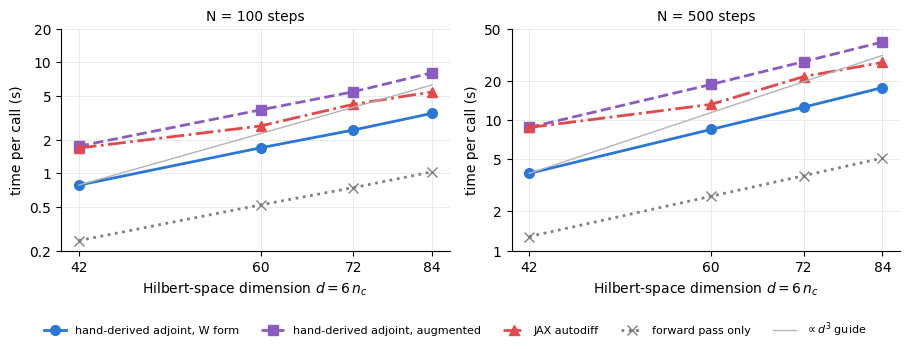

In [18]:
STYLE = {"np_W":   dict(color="#2a78d6", marker="o", ls="-",  label="hand-derived adjoint, W form"),
         "np_aug": dict(color="#8a5cc2", marker="s", ls="--", label="hand-derived adjoint, augmented"),
         "jax":    dict(color="#e34948", marker="^", ls="-.", label="JAX autodiff"),
         "np_fwd": dict(color="0.5",     marker="x", ls=":",  label="forward pass only")}
Ns = sorted(bench.N.unique())
fig, axes = plt.subplots(1, len(Ns), figsize=(4.6 * len(Ns), 3.5))
for ax, N in zip(np.atleast_1d(axes), Ns):
    sub = bench[bench.N == N]
    for mth, st in STYLE.items():
        s_ = sub[sub.method == mth].sort_values("d")
        ax.plot(s_.d, s_.t_min_s, lw=2, ms=7, **st)
    d_ref = np.array(sorted(sub.d.unique()), dtype=float)
    w_ = sub[sub.method == "np_W"].sort_values("d").t_min_s.to_numpy()
    ax.plot(d_ref, w_[0] * (d_ref / d_ref[0]) ** 3, color="0.7", lw=1, label=r"$\propto d^3$ guide")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.xaxis.set_minor_locator(plt.NullLocator()); ax.yaxis.set_minor_locator(plt.NullLocator())
    ax.set_xticks(d_ref); ax.set_xticklabels([f"{v:.0f}" for v in d_ref])
    lo, hi = sub.t_min_s.min(), sub.t_min_s.max()
    yt = [v for v in (0.2, 0.5, 1, 2, 5, 10, 20, 50, 100) if lo / 1.3 <= v <= hi * 2.5]
    ax.set_yticks(yt); ax.set_yticklabels([f"{v:g}" for v in yt])
    ax.set_xlabel(r"Hilbert-space dimension $d = 6\,n_c$")
    ax.set_ylabel("time per call (s)")
    ax.set_title(f"N = {N} steps", fontsize=10)
    tidy(ax)
handles, labels = np.atleast_1d(axes)[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, fontsize=8)
fig.tight_layout(rect=(0, 0.09, 1, 1))
fig.savefig("figures/dgrape_gradient_benchmark.png", dpi=150)
plt.show()

**Figure 3.** Time per fidelity-plus-gradient call (minimum over repeats). Every method is linear in $N$, and the
ratios between methods are the same at both $N$.

**Reading Tables 10–11 and Figure 3.**

- **The hand-derived W form is the fastest exact gradient**: 1.6–2.2× faster than JAX at every size measured. It
  costs 3.0–3.5 forward passes, matching §6.2's estimate of about three.
- **The augmented form costs 2.2× the W form**, about seven forward passes, as §6.3 predicts. It is a reference,
  not a production path.
- **The gap to JAX narrows** from 2.2× at $d = 42$ to about 1.6× from $d = 60$. Matrix products dominate there, and
  both paths do the same products. JAX also needs 580–860 MB, about 500 MB of which is its runtime, against
  64–312 MB for the W form. Its first call adds 8–35 s of compilation.
- **Growth is slower than $d^3$** across this range. At these sizes the $O(d^2)$ gathers and Python overhead still
  matter.

The W form is the default (`backend="np"`). JAX stays as the autodiff cross-check, and as the quickest way to
prototype a new cost term, which needs no hand derivation there.

**Budget for the run in §10** ($N = 550$, $n_c \in \{10, 12\}$). The cell scales the $N = 500$ timings to $N = 550$
and sums the two truncations. The benchmark pulse has $m = 31$–32. At the recipe's amplitudes $m \approx 27$
(§5.4), which is about 15 % cheaper. L-BFGS-B makes slightly more than one evaluation per iteration.

**Budget at the new defaults** ($n_c \in \{12, 14, 16\}$, forbidden-state term on, `--higher-order`). Measured once
at $N = 100$ on a random pulse ($\sigma = 10$ rad/μs), not in the benchmark table: 8.4 s per cost-plus-gradient
serially and 4.2 s with `n_jobs=3`; with the forbidden-state term, 10.9 s and 5.7 s. Parallel jobs give 2.0×,
not 3×, because the $n_c = 16$ job is the slowest and the others wait for it. The forbidden-state term adds
about 30 %: its costate rides along the fidelity's backward pass. Scaled to $N = 550$, one evaluation is about
31 s, so 1000 iterations take roughly 10 h on an uncontended machine.

**More jobs than truncations.** One job uses one core: Accelerate does not thread products this small. A
truncation's three process inputs never interact, so `n_jobs` above the number of truncations splits the largest
truncations by input. Measured at $N = 200$ on $[12, 14, 16]$ with the forbidden-state term on (minimum of 3,
reproduced in reverse order to within 2 %):

| `n_jobs` | split by input | time per evaluation (s) | vs 3 jobs |
|:-:|:-:|:-:|:-:|
| 1 | — | 21.6 | 0.53× |
| 3 | — | 11.4 | 1× |
| 5 | $n_c = 16$ | 9.1 | 1.25× |
| 7 | $n_c = 14, 16$ | 7.7 | 1.48× |
| 9 | all | 6.9 | 1.65× |

Nine jobs bring the 1000-iteration estimate down to about 6 h.

In [19]:
w500 = bench[(bench.method == "np_W") & (bench.N == 500)].set_index("n_c")
per_eval = (w500.loc[10, "t_min_s"] + w500.loc[12, "t_min_s"]) * 550 / 500
print(f"one cost+gradient evaluation at N = 550, n_c = [10, 12]: {per_eval:.0f} s at the benchmark's m, "
      f"~{per_eval * 27 / 31.5:.0f} s at m = 27")
for evals_per_it in (1.1, 1.3):
    print(f"1000 iterations x {evals_per_it} evaluations: {1000 * evals_per_it * per_eval * 27 / 31.5 / 3600:.1f} h "
          f"(uncontended machine)")

one cost+gradient evaluation at N = 550, n_c = [10, 12]: 23 s at the benchmark's m, ~20 s at m = 27
1000 iterations x 1.1 evaluations: 6.1 h (uncontended machine)
1000 iterations x 1.3 evaluations: 7.2 h (uncontended machine)


# 10. First training run: X gate

The first trained gate is the logical X on the kitten code, trained on the full recipe of §7 with the higher-order
terms on:

```bash
python3 DGRAPE/train.py --gate X --duration-us 1.1 --dt 0.002 --n-c 10 12 \
    --max-iter 1000 --higher-order --seed 42 --tag X_open_d1
```

The output files are `pulses/dgrape/u_X_open_d1.npy` (pulse), `x_X_open_d1.npy` (pre-image, for an exact resume),
`X_open_d1.json` (settings, report, per-iteration history) and the log `logs/dgrape_X_open_d1.log`. The cells below
load these files and re-score the pulse; nothing is retrained here.

In [20]:
import json

RUN = "X_open_d1"
with open(f"pulses/dgrape/{RUN}.json") as fh:
    info = json.load(fh)
u_X = np.load(f"pulses/dgrape/u_{RUN}.npy")
x_X = np.load(f"pulses/dgrape/x_{RUN}.npy")
N_X, DT_X = info["N"], info["dt"]
hist = pd.DataFrame(info["history"])
settings = {
    "gate, duration": f"{info['gate']}, {N_X * DT_X:.2f} μs (N = {N_X}, dt = {DT_X * 1e3:.0f} ns)",
    "truncations": info["trunc_list"], "jump operators": info["c_ops"],
    "bands (MHz)": f"cavity {info['cav_band']}, transmon {info['tra_band']}", "ramp (ns)": info["ramp_ns"],
    "penalties (amp_max in rad/μs)": info["penalties"], "hard_amp_limit (rad/μs)": info["hard_amp_limit"], "seed, start": f"{info['seed']}, {info['warm_start_kind']}",
    "iterations (max)": f"{info['nit']} ({info['maxiter']})", "cost evaluations": info["n_evals"],
    "wall time": f"{info['wall_s'] / 3600:.1f} h", "optimizer message": info["message"], "returned": info["returned"],
}
display(pd.DataFrame(settings.items(), columns=["setting", "value"]).style.hide(axis="index")
        .set_caption("Table 12. Run settings and outcome"))

setting,value
"gate, duration","X, 1.10 μs (N = 550, dt = 2 ns)"
truncations,"[10, 12]"
jump operators,"['a', 'r', 's_ge', 's_ef']"
bands (MHz),"cavity [-27.0, 27.0], transmon [-33.0, 33.0]"
ramp (ns),48.000000
penalties (amp_max in rad/μs),"{'deriv': 1e-05, 'amp': 8e-05, 'amp_max': 25.0, 'disc': 0.5}"
hard_amp_limit (rad/μs),25.000000
"seed, start","42, cold"
iterations (max),1000 (1000)
cost evaluations,1087


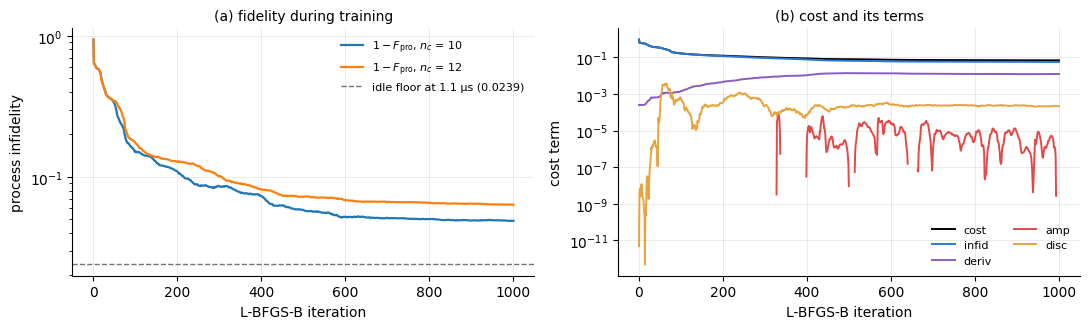

In [21]:
F_hist = np.array(hist["F_pro"].tolist())
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ax = axes[0]
for i, nc in enumerate(info["trunc_list"]):
    ax.semilogy(hist["it"], 1 - F_hist[:, i], lw=1.6, label=f"$1 - F_{{\\rm pro}}$, $n_c$ = {nc}")
ax.axhline(IDLE_FLOOR, color="0.45", ls="--", lw=1, label=f"idle floor at 1.1 μs ({IDLE_FLOOR:.4f})")
ax.set_xlabel("L-BFGS-B iteration"); ax.set_ylabel("process infidelity")
ax.set_title("(a) fidelity during training", fontsize=10)
ax.legend(frameon=False, fontsize=8)
tidy(ax)
ax = axes[1]
for key, col in [("cost", "k"), ("infid", "#2a78d6"), ("deriv", "#8a5cc2"), ("amp", "#e34948"), ("disc", "#e8a33d")]:
    if key in hist and (hist[key] > 0).any():
        ax.semilogy(hist["it"], hist[key].where(hist[key] > 0), lw=1.4, color=col, label=key)   # gaps: term exactly 0
ax.set_xlabel("L-BFGS-B iteration"); ax.set_ylabel("cost term")
ax.set_title("(b) cost and its terms", fontsize=10)
ax.legend(frameon=False, fontsize=8, ncol=2)
tidy(ax)
fig.tight_layout()
fig.savefig("figures/dgrape_X_convergence.png", dpi=150)
plt.show()

**Figure 4.** Training history. (a) Process infidelity on each training truncation, against the idle floor of
Fig. 1. (b) Total cost and its weighted terms (`infid` $= 1-\bar F_{\rm pro}$; `disc`, `deriv`, `amp` as in §7.1).

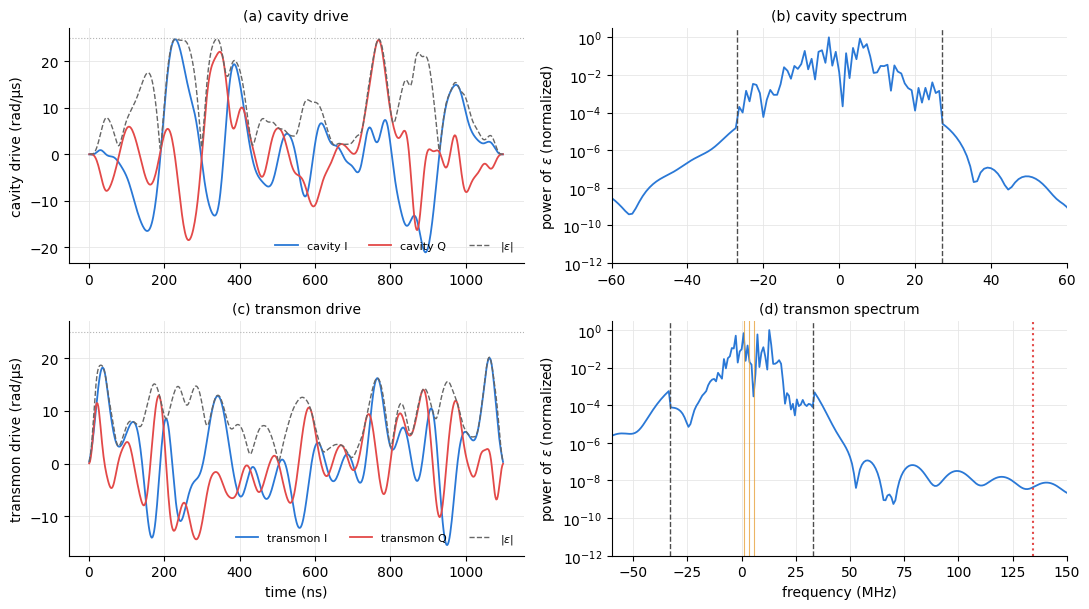

In [22]:
t_ns_X = (np.arange(N_X) + 0.5) * DT_X * 1e3
freq_X = np.fft.fftshift(np.fft.fftfreq(N_X, d=DT_X))
fig, axes = plt.subplots(2, 2, figsize=(11, 6.2))
labels = ["I", "Q"]
for row, (drive, cols, band) in enumerate([("cavity", (0, 1), info["cav_band"]), ("transmon", (2, 3), info["tra_band"])]):
    ax = axes[row, 0]
    for c, lab, col in zip(cols, labels, ("#2a78d6", "#e34948")):
        ax.plot(t_ns_X, u_X[:, c], lw=1.3, color=col, label=f"{drive} {lab}")
    ax.plot(t_ns_X, np.hypot(u_X[:, cols[0]], u_X[:, cols[1]]), lw=1, color="0.4", ls="--", label=r"$|\epsilon|$")
    ax.axhline(info["penalties"]["amp_max"], color="0.7", lw=0.8, ls=":")
    ax.set_ylabel(f"{drive} drive (rad/μs)")
    ax.set_title(f"({'ac'[row]}) {drive} drive", fontsize=10)
    ax.legend(frameon=False, fontsize=8, ncol=3, loc="lower right")
    tidy(ax)
    ax = axes[row, 1]
    p = power(u_X[:, cols[0]], u_X[:, cols[1]])
    ax.semilogy(freq_X, np.maximum(p / p.max(), 1e-14), color="#2a78d6", lw=1.3)
    for edge in band:
        ax.axvline(edge, color="0.3", ls="--", lw=1)
    if drive == "transmon":
        for n in (1, 3, 5):
            ax.axvline(n * dev.chi_ge / TWO_PI, color="#e8a33d", lw=0.8, alpha=0.8)
        ax.axvline(dev.alpha_q / TWO_PI, color="#e34948", ls=":", lw=1.5)
    ax.set_xlim(-60, 150 if drive == "transmon" else 60); ax.set_ylim(1e-12, 3)
    ax.set_ylabel(r"power of $\epsilon$ (normalized)")
    ax.set_title(f"({'bd'[row]}) {drive} spectrum", fontsize=10)
    tidy(ax)
axes[1, 0].set_xlabel("time (ns)"); axes[1, 1].set_xlabel("frequency (MHz)")
fig.tight_layout()
fig.savefig("figures/dgrape_X_pulse.png", dpi=150)
plt.show()

**Figure 5.** The trained X pulse. (a, c) Quadratures and the drive modulus $|\epsilon|$; the dotted line is
$u_{\max} = 25$ rad/μs. (b, d) Spectra of $\epsilon_C$ and $\epsilon_T$; dashed lines are the band edges. Frequencies
are offsets from the frame, i.e. from the bare transmon $g\to e$ frequency (the $n = 0$ line sits at 0). In (d):

- **orange solid lines**: the $g\to e$ transition frequencies with the storage in Fock state $n = 1, 3, 5$ (the code's
  photon numbers), at $n\chi_{ge}/2\pi$ = 1.12, 3.36, 5.60 MHz;
- **red dotted line**: the $e\to f$ transition frequency with the storage in vacuum ($n = 0$), at $\alpha_q/2\pi$ =
  134.28 MHz.

Physically both transitions move *down* with $n$ (the $-\chi_{ge}|e\rangle\langle e|\hat a^\dagger\hat a - \chi_{gf}|f\rangle\langle f|\hat a^\dagger\hat a$ terms of §2.2); the
spectrum of $\epsilon = I - iQ$ under numpy's FFT sign convention plots them at positive offsets.

**Why one $e\to f$ line suffices.** The $e\to f$ line also depends on the storage population:
$\omega_{ef}(n) = \omega_q - \alpha_q - n\chi_{ef}$, plotted at $(\alpha_q + n\chi_{ef})/2\pi$ = 134.28, 135.2, 137.1,
139.0 MHz for $n = 0, 1, 3, 5$. It is somewhat less sensitive to $n$ than the $g\to e$ line ($\chi_{ef}/2\pi = 0.95$ vs
$\chi_{ge}/2\pi = 1.12$ MHz per photon), but the decisive point is scale: the whole $n \le 5$ cluster spans 4.75 MHz
and lies ~100 MHz beyond the $\pm33$ MHz band edge, so the filter blocks every one of these lines equally. The $g\to e$
lines are drawn individually because their $n$-dependence is what the pulse uses: power at $n\chi_{ge}$ is a
photon-number-selective qubit rotation.

## 10.1 Scoring the pulse beyond its training conditions

The pulse is re-scored under conditions it was not trained on:

- **Held-out truncations** $n_c = 14, 16, 18$. If the score matches the training values, the pulse does not exploit
  the truncation edge, and $[10, 12]$ was enough. The largest value at which the score stops changing is the
  pulse's physical fidelity.
- **All channels**: dephasing and heating added. The gap shows how much the decay-only training model leaves out.
- **Higher-order terms off**: the same pulse under Eq. (2) as printed. The gap measures how much of the pulse is
  compensating Kerr and $\chi'_q$.
- **Closed system** (every rate set to 0): the coherent error alone. Comparing it with the open-system score
  separates control error from dissipation.

In [23]:
def score(n_c, label, **kw):
    kw.setdefault("include_higher_order", True)
    mdl = Model(n_c, **kw)
    E, Theta, w = process_targets("X", n_c)
    F = lnp.fidelity(mdl, u_X, E, Theta, w, DT_X)
    return {"condition": label, "n_c": n_c, "F_pro": F, "F_avg": (2 * F + 1) / 3, "1 - F_pro": 1 - F}


scores = [score(10, "training (decay only)"), score(12, "training (decay only)"),
          score(14, "held-out truncation"), score(16, "held-out truncation"), score(18, "held-out truncation"),
          score(12, "all channels", dephasing=True, heating=True),
          score(12, "higher-order terms off", include_higher_order=False),
          score(12, "closed system (no dissipation)", rate_scale=0.0)]
score_table = pd.DataFrame(scores)
display(score_table.style.format({"F_pro": "{:.6f}", "F_avg": "{:.6f}", "1 - F_pro": "{:.2e}"}).hide(axis="index")
        .set_caption("Table 13. The trained X pulse under different models"))
F12, F_conv = score_table.F_pro[1], score_table.F_pro[4]          # n_c = 12 and n_c = 18
print(f"drift from training to converged truncation |F(18) - F(12)| = {abs(F_conv - F12):.1e}; "
      f"|F(18) - F(16)| = {abs(F_conv - score_table.F_pro[3]):.1e}")
print(f"idle floor at 1.1 μs = {IDLE_FLOOR:.4f}; converged 1 - F_pro = {1 - F_conv:.4f} "
      f"({(1 - F_conv) / IDLE_FLOOR:.1f}x the floor)")

condition,n_c,F_pro,F_avg,1 - F_pro
training (decay only),10,0.951155,0.967437,4.88e-02
training (decay only),12,0.936532,0.957688,6.35e-02
held-out truncation,14,0.918330,0.945553,8.17e-02
held-out truncation,16,0.915549,0.943699,8.45e-02
held-out truncation,18,0.915404,0.943603,8.46e-02
all channels,12,0.925001,0.950001,7.50e-02
higher-order terms off,12,0.924078,0.949385,7.59e-02
closed system (no dissipation),12,0.972156,0.981438,2.78e-02


drift from training to converged truncation |F(18) - F(12)| = 2.1e-02; |F(18) - F(16)| = 1.4e-04
idle floor at 1.1 μs = 0.0239; converged 1 - F_pro = 0.0846 (3.5x the floor)


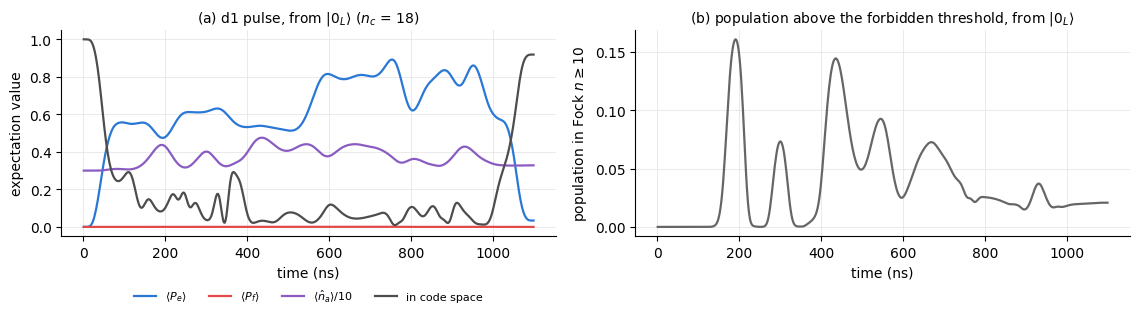

time-averaged transmon excitation P_e + P_f = 0.604; max <n_a> = 4.76
population in Fock n >= 10: max = 0.161, at the end = 0.021, time-summed = 20.9
code-space population: min = 0.01, at the end = 0.919


In [24]:
# Where the population goes: start in |0_L>, training model at the converged truncation n_c = 18
mdl12 = Model(18, include_higher_order=True)
VL12 = embedded_basis(18)
rho_in = np.outer(VL12[:, 0], VL12[:, 0].conj())[None]
rho_end, traj = lnp.propagate(mdl12, u_X, rho_in, DT_X, store=True)
traj = np.stack([r[0] for r in traj])                     # (N, d, d), state at the start of each step
ops12 = operators(18)
P_code = VL12 @ VL12.conj().T
n_fock = np.arange(mdl12.d) // 6
tail = np.array([np.real(np.diag(r))[n_fock >= 10].sum() for r in traj])
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
ax = axes[0]
pops = {r"$\langle P_e\rangle$": ops12["Pe"], r"$\langle P_f\rangle$": ops12["Pf"],
        r"$\langle \hat n_a\rangle / 10$": ops12["n_a"] / 10, "in code space": P_code}
for (lab, op), col in zip(pops.items(), ("#2a78d6", "#e34948", "#8a5cc2", "0.3")):
    ax.plot(t_ns_X, np.real(np.einsum("ij,kji->k", op, traj)), lw=1.6, color=col, label=lab)
ax.set_xlabel("time (ns)"); ax.set_ylabel("expectation value")
ax.set_title(r"(a) d1 pulse, from $|0_L\rangle$ ($n_c$ = 18)", fontsize=10)
ax.legend(frameon=False, fontsize=8, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.2))
tidy(ax)
ax = axes[1]
ax.plot(t_ns_X, tail, lw=1.6, color="0.4")
ax.set_xlabel("time (ns)"); ax.set_ylabel(r"population in Fock $n \geq 10$")
ax.set_title(r"(b) population above the forbidden threshold, from $|0_L\rangle$", fontsize=10)
tidy(ax)
fig.tight_layout()
fig.savefig("figures/dgrape_X_trajectory.png", dpi=150)
plt.show()
mean_exc = np.mean([np.real(np.trace((ops12["Pe"] + ops12["Pf"]) @ r)) for r in traj])
code_pop = np.real(np.einsum("ij,kji->k", P_code, traj))
print(f"time-averaged transmon excitation P_e + P_f = {mean_exc:.3f}; "
      f"max <n_a> = {np.real(np.einsum('ij,kji->k', ops12['n_a'], traj)).max():.2f}")
print(f"population in Fock n >= 10: max = {tail.max():.3f}, at the end = {np.real(np.diag(rho_end[0]))[n_fock >= 10].sum():.3f}, time-summed = {tail.sum():.1f}")
print(f"code-space population: min = {code_pop.min():.2f}, at the end = {np.real(np.trace(P_code @ rho_end[0])):.3f}")

**Figure 6.** The trained X pulse (d1) acting on $|0_L\rangle$, in the training model (decay only, higher-order
terms on) at the converged truncation $n_c = 18$. (a) Transmon excitation, photon number and code-space population.
(b) Population above the forbidden threshold, Fock $n \ge 10$.

**Purpose.** Table 13 says *how much* the gate loses. This figure shows *where the population goes* during the gate,
to explain two things: why the gate loses more than the idle floor, and why the training truncation $[10, 12]$
failed. It is run at $n_c = 18$, not $[10, 12]$, so the dynamics are represented faithfully.

**The curves.** Each is an expectation value $\langle\hat O\rangle(t) = \mathrm{Tr}[\hat O\,\hat\rho(t)]$ of the state started in
$|0_L, g, 0\rangle$.

| panel | curve | operator $\hat O$ | meaning |
|:-:|---|---|---|
| (a) | $\langle P_e\rangle$ | $\lvert e\rangle\langle e\rvert$ on the transmon | probability the transmon is in $\lvert e\rangle$ |
| (a) | $\langle P_f\rangle$ | $\lvert f\rangle\langle f\rvert$ on the transmon | probability the transmon is in $\lvert f\rangle$ |
| (a) | $\langle\hat n_a\rangle/10$ | storage photon number ÷ 10 | mean photon number, scaled to fit (0.3 = 3 photons) |
| (a) | in code space | $V_LV_L^\dagger$ | probability of being in the code: storage in $\{\lvert 0_L\rangle, \lvert 1_L\rangle\}$, transmon in $g$, readout in 0 |
| (b) | Fock $n \ge 10$ | $P_F = \sum_{n\ge10}\lvert n\rangle\langle n\rvert$ | population the forbidden-state penalty (§7) charges for |

**What it shows.**

- **The gate leaves the code on purpose.** Within about 80 ns the transmon is excited and the code-space population
  falls to about 0.25. It stays mostly below 0.1 until the last 100 ns. The pulse uses the transmon as a lever on the
  photon number, and only the endpoints are scored. By the end, 0.92 has returned.
- **The transmon is excited for most of the gate**, $\overline{P_e + P_f} = 0.60$. It decays at $T_1^{ge} = 50$ μs,
  which costs roughly $0.6 \times 1.1/50 \approx 1.3\%$. That is about the gap between the gate's dissipation (3.6 %)
  and the idle floor (2.4 %). The same excitation is why adding dephasing costs a further 1.2 % (Table 13).
- **$\langle P_f\rangle$ stays at 0.** The $e\to f$ line lies outside the transmon band (§7), so leakage to $\lvert f\rangle$
  is blocked by construction.
- **The mean photon number hides the tail.** $\langle\hat n_a\rangle$ never exceeds 4.8, yet the pulse throws population
  above Fock 10 in bursts (b): up to 16 % near 190 ns and 14 % near 430 ns. 2 % is still there at the end. A 10- or
  12-level simulation cannot represent those states, so training partly optimized a truncation artefact. That is why
  the score falls from 0.937 at $n_c = 12$ to 0.915 converged. The time-summed tail, 20.9, is the $\lvert 0_L\rangle$ half
  of the forbidden-state cost this pulse would have been charged (§11 trains with it).
- **Being in the code is not the same as being correct.** "In code space" counts both code words, and this is only
  one input. $F_{\rm pro}$ also needs the population in $\lvert 1_L\rangle$ and the right relative phase, so it is
  0.915, not 0.92.

## 10.2 Constraint report

In [25]:
c = info["constraints"]
amp_max = info["penalties"]["amp_max"]
checks_X = [
    ("peak |eps_C| (rad/μs)", info["max_drive_modulus"]["cav"], f"<= {amp_max}", info["max_drive_modulus"]["cav"] <= amp_max * 1.001),
    ("peak |eps_T| (rad/μs)", info["max_drive_modulus"]["tra"], f"<= {amp_max}", info["max_drive_modulus"]["tra"] <= amp_max * 1.001),
    ("max |x|, pre-image (rad/μs)", info["max_abs_preimage"], f"< {info['hard_amp_limit']}", info["max_abs_preimage"] < info["hard_amp_limit"]),
    ("fraction of x pinned at the box", info["frac_preimage_pinned"], "= 0", info["frac_preimage_pinned"] == 0),
    ("endpoint / peak amplitude", c["endpoint_rel_to_peak"], "small (ramp)", True),
    ("out-of-band energy, cavity (fraction)", c["out_of_band_cavity"], "small", True),
    ("out-of-band energy, transmon (fraction)", c["out_of_band_transmon"], "small", True),
    ("held-out drift |F(18) - F(12)|", abs(F_conv - F12), "<= 1e-4", abs(F_conv - F12) <= 1e-4),
]
display(pd.DataFrame(checks_X, columns=["quantity", "value", "requirement", "ok"])
        .style.format({"value": "{:.4g}"}).hide(axis="index").set_caption("Table 14. Is the pulse trustworthy?"))

quantity,value,requirement,ok
peak |eps_C| (rad/μs),24.84,<= 25.0,True
peak |eps_T| (rad/μs),20.17,<= 25.0,True
"max |x|, pre-image (rad/μs)",25,< 25.0,False
fraction of x pinned at the box,0.02,= 0,False
endpoint / peak amplitude,0.01256,small (ramp),True
"out-of-band energy, cavity (fraction)",2.791e-05,small,True
"out-of-band energy, transmon (fraction)",0.0009661,small,True
held-out drift |F(18) - F(12)|,0.02113,<= 1e-4,False


## 10.3 Verdict: the pipeline works, this pulse is not a usable gate

**The physical fidelity is $F_{\rm pro} = 0.9154$, not the 0.944 training reported.** The score falls with every
added Fock level (0.951 → 0.937 → 0.918 at $n_c$ = 10, 12, 14) and settles only at $n_c \ge 16$ (Table 13). This is
the failure Eq. 24 exists to catch: the pulse drives up to 16 % of the population above Fock 10 mid-gate (Fig. 6),
where a truncation at 10 or 12 misrepresents the dynamics. At $\lambda_{\rm disc} = 0.5$ the penalty was
$0.5 \times 2 \times 0.015^2 \approx 2\times10^{-4}$, against an infidelity of 0.06. It was far too weak to
matter. **The guessed truncation list $[10, 12]$ is falsified for this recipe.**

**Error budget** (at $n_c = 12$, where every variant was scored; the rows overlap slightly and are not strictly additive):

| contribution | size | evidence |
|---|:-:|---|
| coherent control error | 2.8 % | closed-system score 0.972 |
| dissipation | 3.6 % | 0.972 → 0.937. The idle floor is 2.4 %; the excess comes from the transmon sitting in $\lvert e\rangle$ most of the gate (Fig. 6) |
| truncation artefact | 2.1 % | 0.937 at $n_c = 12$ → 0.9154 converged |
| missing dephasing and heating | 1.2 % | all-channels score 0.925, again driven by transmon excitation |

**The higher-order terms matter, as §2.4 predicted.** Scoring the same pulse without them drops $F_{\rm pro}$ from
0.937 to 0.924. The optimizer used them, and a pulse trained on Eq. (2) alone would carry that 1.2 % error.

**Constraints.**
- **The pulse is amplitude-limited**: $|\epsilon_C|$ peaks at 24.8 rad/μs, against the 25 cap, and 2 % of the
  pre-image is pinned at the box. In this repository's convention a pinned pre-image means the pulse was clipped,
  not converged.
- **The derivative penalty is binding**: it is 0.012 of the final cost of 0.069, about 18 %.
- **Leakage to $\lvert f\rangle$ stays negligible**, so the band filter does its job.
- **The optimizer had not converged**: it used all 1000 iterations (1087 evaluations), and the cost was still falling
  slowly.

**What to change for the next run** (also §12):
1. **Train at a converged truncation, and drop the readout to pay for it.** The readout is inert (§8.2 shows $n_r = 1$
   reproduces $n_r = 2$ exactly). With `n_r=1`, $n_c = 18$ has $d = 54$, smaller than this run's $d = 72$. Training on
   $[16, 18]$ without the readout costs about the same as $[10, 12]$ with it. `train.py` needs an `--n-r` option.
2. **Raise $\lambda_{\rm disc}$** by orders of magnitude, or penalize the population in the top Fock levels directly.
3. **Revisit duration and amplitude.** A gate that pins the box at 1.1 μs is short of control authority. Scan
   $T_g$, or relax `hard_amp_limit`, since Shirol publish no drive limit.
4. **Train with dephasing on**, since this pulse keeps the transmon excited.
5. Run more iterations, with checkpointing and the truncations evaluated in parallel.

The run did establish two things: exact open-system GRAPE trains end to end on this chip, and the diagnostics in
this section are enough to tell a clipped, truncation-exploiting pulse from a usable one.

# 11. Second training run: X gate at the new defaults

The second X run uses the command from §12, with only `--n-jobs` raised to 9 (§9):

```bash
python3 DGRAPE/train.py --gate X --duration-us 1.1 --dt 0.002 --max-iter 1000 --higher-order \
    --n-jobs 9 --tag X_open_d2
```

It keeps the gate, duration, seed, cold start, bands, ramp and penalty weights of §10. Two things change, both taken
from §10.3:

- **Truncations $[12, 14, 16]$** instead of $[10, 12]$. Every entry is above the forbidden threshold.
- **The forbidden-state penalty** (§7.1), $\lambda_{\rm forbid} = 10^{-3}$ on storage Fock $\ge 10$.

The files are `pulses/dgrape/u_X_open_d2.npy`, `x_X_open_d2.npy`, `X_open_d2.json` and `logs/dgrape_X_open_d2.log`.
As in §10, the cells below only load and re-score them. Nothing is retrained. Variables carry a `2` suffix so that
the §10 results stay in scope.

In [26]:
RUN2 = "X_open_d2"
with open(f"pulses/dgrape/{RUN2}.json") as fh:
    info2 = json.load(fh)
with open("pulses/dgrape/X_open_d1.json") as fh:
    info1 = json.load(fh)                                       # the §10 run, for comparison
u_X2 = np.load(f"pulses/dgrape/u_{RUN2}.npy")
x_X2 = np.load(f"pulses/dgrape/x_{RUN2}.npy")
u_X1 = np.load("pulses/dgrape/u_X_open_d1.npy")
N_X2, DT_X2 = info2["N"], info2["dt"]
hist2 = pd.DataFrame(info2["history"])


def run_summary(d):
    pt = d["per_trunc"]
    return {
        "truncations n_c": str(d["trunc_list"]),
        "lambda_forbid (Fock >= 10)": f"{d['penalties'].get('forbid', 0.0):g}",
        "parallel jobs": str(d.get("n_jobs", 1)),
        "iterations (max)": f"{d['nit']} ({d['maxiter']})",
        "cost evaluations": d["n_evals"],
        "wall time": f"{d['wall_s'] / 3600:.1f} h",
        "seconds per evaluation": f"{d['wall_s'] / d['n_evals']:.0f}",
        "optimizer message": d["message"],
        "training F_pro per n_c": ", ".join(f"{r['F_pro']:.4f}" for r in pt),
        "C_forbid per n_c": ", ".join(f"{r['C_forbid']:.1f}" for r in pt) if "C_forbid" in pt[0] else "not computed",
        "final cost": f"{d['history'][-1]['cost']:.4f}",
        "peak |eps_C|, |eps_T| (rad/μs)": f"{d['max_drive_modulus']['cav']:.2f}, {d['max_drive_modulus']['tra']:.2f}",
        "max |x|, fraction pinned": f"{d['max_abs_preimage']:.2f}, {100 * d['frac_preimage_pinned']:.2f} %",
    }


common = (f"{info2['gate']}, {N_X2 * DT_X2:.2f} μs (N = {N_X2}, dt = {DT_X2 * 1e3:.0f} ns); seed {info2['seed']}, "
          f"{info2['warm_start_kind']} start; jump operators {info2['c_ops']}; returned {info2['returned']}")
print("shared by both runs:", common)
display(pd.DataFrame({"§10: X_open_d1": run_summary(info1), "§11: X_open_d2": run_summary(info2)})
        .style.set_caption("Table 15. The two X runs side by side"))


shared by both runs: X, 1.10 μs (N = 550, dt = 2 ns); seed 42, cold start; jump operators ['a', 'r', 's_ge', 's_ef']; returned best_seen


,§10: X_open_d1,§11: X_open_d2
truncations n_c,"[10, 12]","[12, 14, 16]"
lambda_forbid (Fock >= 10),0,0.001
parallel jobs,1,9
iterations (max),1000 (1000),1000 (1000)
cost evaluations,1087,1097
wall time,19.5 h,10.3 h
seconds per evaluation,65,34
optimizer message,STOP: TOTAL NO. of ITERATIONS REACHED LIMIT,STOP: TOTAL NO. of ITERATIONS REACHED LIMIT
training F_pro per n_c,"0.9512, 0.9365","0.9572, 0.9564, 0.9556"
C_forbid per n_c,not computed,"8.9, 9.9, 10.1"


**Reading Table 15.** Both runs used all 1000 iterations. The new run took about half the wall time, despite the
larger truncations: 34 s per evaluation against 65 s, because the truncations were split across 9 jobs. That is
slower than the roughly 19 s that §9 predicts (6.9 s at $N = 200$, scaled to $N = 550$). Wall time includes any machine
contention, so it is not a benchmark. At every truncation, the training $F_{\rm pro}$ is above the §10 run's.

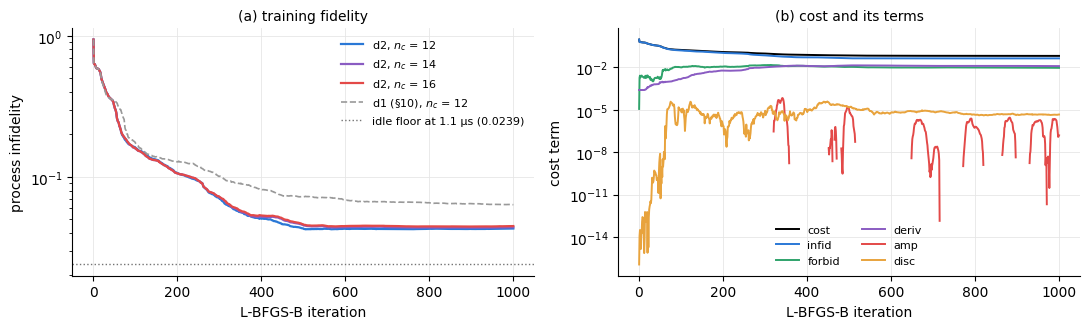

final cost 0.0657 = infid 0.0439 + forbid 0.0093 + deriv 0.0125 + disc 4.6e-06 + amp 1.6e-07
cost falls 4.5 % over iterations 500-750
cost falls 1.1 % over iterations 750-1000


In [27]:
F_hist2 = np.array(hist2["F_pro"].tolist())
F_hist1 = np.array([h["F_pro"] for h in info1["history"]])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ax = axes[0]
for i, (nc, col) in enumerate(zip(info2["trunc_list"], ("#2a78d6", "#8a5cc2", "#e34948"))):
    ax.semilogy(hist2["it"], 1 - F_hist2[:, i], lw=1.6, color=col, label=f"d2, $n_c$ = {nc}")
ax.semilogy([h["it"] for h in info1["history"]], 1 - F_hist1[:, 1], lw=1.2, color="0.6", ls="--",
            label="d1 (§10), $n_c$ = 12")
ax.axhline(IDLE_FLOOR, color="0.45", ls=":", lw=1, label=f"idle floor at 1.1 μs ({IDLE_FLOOR:.4f})")
ax.set_xlabel("L-BFGS-B iteration"); ax.set_ylabel("process infidelity")
ax.set_title("(a) training fidelity", fontsize=10)
ax.legend(frameon=False, fontsize=8)
tidy(ax)
ax = axes[1]
for key, col in [("cost", "k"), ("infid", "#2a78d6"), ("forbid", "#2fa36b"), ("deriv", "#8a5cc2"),
                 ("amp", "#e34948"), ("disc", "#e8a33d")]:
    if key in hist2 and (hist2[key] > 0).any():
        ax.semilogy(hist2["it"], hist2[key].where(hist2[key] > 0), lw=1.4, color=col, label=key)
ax.set_xlabel("L-BFGS-B iteration"); ax.set_ylabel("cost term")
ax.set_title("(b) cost and its terms", fontsize=10)
ax.legend(frameon=False, fontsize=8, ncol=2)
tidy(ax)
fig.tight_layout()
fig.savefig("figures/dgrape_X_d2_convergence.png", dpi=150)
plt.show()
last = hist2.iloc[-1]
print(f"final cost {last.cost:.4f} = infid {last.infid:.4f} + forbid {last.forbid:.4f} + deriv {last.deriv:.4f} "
      f"+ disc {last.disc:.1e} + amp {last.amp:.1e}")
for lo, hi in [(500, 750), (750, 1000)]:
    c0, c1 = hist2.cost[hist2.it == lo].item(), hist2.cost[hist2.it == hi].item()
    print(f"cost falls {100 * (c0 - c1) / c0:.1f} % over iterations {lo}-{hi}")


**Figure 7.** Training history of the d2 run. (a) Process infidelity on each training truncation; the dashed
curve is the §10 run's $n_c = 12$. The three d2 curves lie on top of each other, while the d1 curves split apart
(Fig. 4). (b) Total cost and its weighted terms. `forbid` is $\lambda_{\rm forbid}\,\bar C$ (§7.1).

- **The run has plateaued; it did not run out of iterations.** The cost fell 4.5 % over iterations 500–750 and only
  1.1 % over 750–1000. More iterations from this point would not help much.
- **The forbidden-state term binds.** It is 0.0093 of the final cost of 0.0657 (14 %). The derivative penalty is
  0.0125 (19 %), as binding as in §10. The amplitude and Eq. 24 discrepancy terms are negligible.

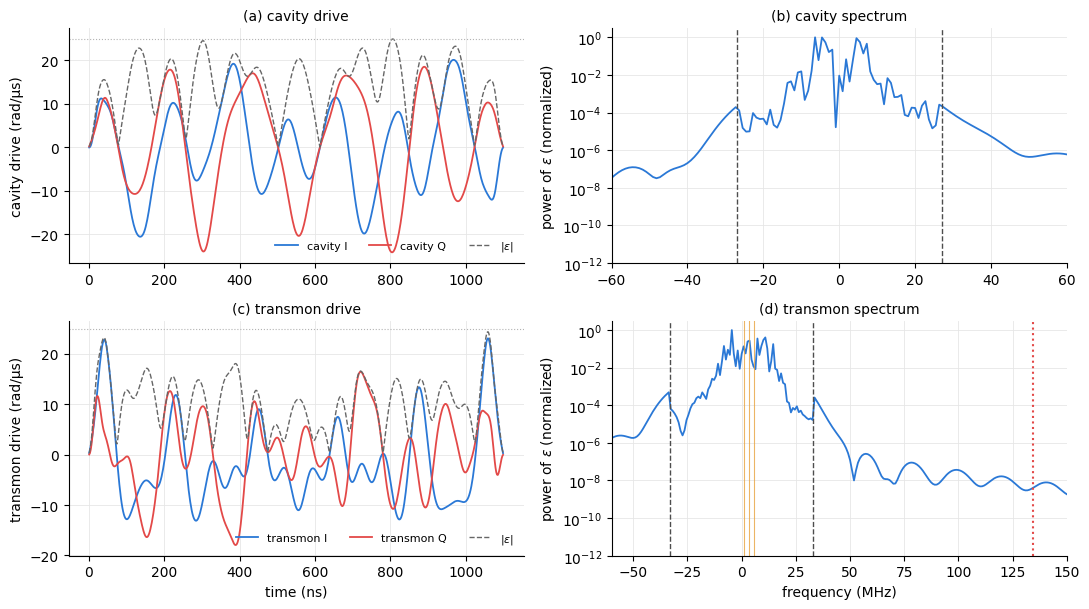

In [28]:
t_ns_X2 = (np.arange(N_X2) + 0.5) * DT_X2 * 1e3
freq_X2 = np.fft.fftshift(np.fft.fftfreq(N_X2, d=DT_X2))
fig, axes = plt.subplots(2, 2, figsize=(11, 6.2))
for row, (drive, cols, band) in enumerate([("cavity", (0, 1), info2["cav_band"]), ("transmon", (2, 3), info2["tra_band"])]):
    ax = axes[row, 0]
    for c, lab, col in zip(cols, ("I", "Q"), ("#2a78d6", "#e34948")):
        ax.plot(t_ns_X2, u_X2[:, c], lw=1.3, color=col, label=f"{drive} {lab}")
    ax.plot(t_ns_X2, np.hypot(u_X2[:, cols[0]], u_X2[:, cols[1]]), lw=1, color="0.4", ls="--", label=r"$|\epsilon|$")
    ax.axhline(info2["penalties"]["amp_max"], color="0.7", lw=0.8, ls=":")
    ax.set_ylabel(f"{drive} drive (rad/μs)")
    ax.set_title(f"({'ac'[row]}) {drive} drive", fontsize=10)
    ax.legend(frameon=False, fontsize=8, ncol=3, loc="lower right")
    tidy(ax)
    ax = axes[row, 1]
    p = power(u_X2[:, cols[0]], u_X2[:, cols[1]])
    ax.semilogy(freq_X2, np.maximum(p / p.max(), 1e-14), color="#2a78d6", lw=1.3)
    for edge in band:
        ax.axvline(edge, color="0.3", ls="--", lw=1)
    if drive == "transmon":
        for n in (1, 3, 5):
            ax.axvline(n * dev.chi_ge / TWO_PI, color="#e8a33d", lw=0.8, alpha=0.8)
        ax.axvline(dev.alpha_q / TWO_PI, color="#e34948", ls=":", lw=1.5)
    ax.set_xlim(-60, 150 if drive == "transmon" else 60); ax.set_ylim(1e-12, 3)
    ax.set_ylabel(r"power of $\epsilon$ (normalized)")
    ax.set_title(f"({'bd'[row]}) {drive} spectrum", fontsize=10)
    tidy(ax)
axes[1, 0].set_xlabel("time (ns)"); axes[1, 1].set_xlabel("frequency (MHz)")
fig.tight_layout()
fig.savefig("figures/dgrape_X_d2_pulse.png", dpi=150)
plt.show()


**Figure 8.** The d2 X pulse, drawn as in Fig. 5. Both drive moduli reach the $u_{\max} = 25$ rad/μs line:
the cavity mid-gate, the transmon in the opening and closing 50 ns. Both spectra stay inside the bands. On the
transmon, the out-of-band power at the $e\to f$ line (red dotted) is below $10^{-8}$ of the peak.

## 11.1 Scoring the pulse beyond its training conditions

The conditions are those of §10.1. The held-out truncations are now $n_c = 18, 20$, both above the training list,
and the model variants are scored at $n_c = 18$ instead of 12. The last row re-scores the §10 pulse in the closed
system at the same $n_c$, so the coherent errors of the two pulses can be compared directly.

In [29]:
def score2(n_c, label, u=u_X2, **kw):
    kw.setdefault("include_higher_order", True)
    mdl = Model(n_c, **kw)
    E, Theta, w = process_targets("X", n_c)
    F = lnp.fidelity(mdl, u, E, Theta, w, DT_X2)
    return {"condition": label, "n_c": n_c, "F_pro": F, "F_avg": (2 * F + 1) / 3, "1 - F_pro": 1 - F}


N_REF = 18                                                    # first held-out truncation
scores2 = [score2(nc, "training (decay only)") for nc in info2["trunc_list"]]
scores2 += [score2(nc, "held-out truncation") for nc in (18, 20)]
scores2 += [score2(N_REF, "all channels", dephasing=True, heating=True),
            score2(N_REF, "higher-order terms off", include_higher_order=False),
            score2(N_REF, "closed system (no dissipation)", rate_scale=0.0),
            score2(N_REF, "§10 pulse (d1), closed system", u=u_X1, rate_scale=0.0)]
score_table2 = pd.DataFrame(scores2)
display(score_table2.style.format({"F_pro": "{:.6f}", "F_avg": "{:.6f}", "1 - F_pro": "{:.2e}"}).hide(axis="index")
        .set_caption("Table 16. The d2 X pulse under different models"))
F2 = dict(zip(zip(score_table2.condition, score_table2.n_c), score_table2.F_pro))
F2_train, F2_conv = F2[("training (decay only)", 16)], F2[("held-out truncation", 20)]
print(f"|F(20) - F(16)| = {abs(F2_conv - F2_train):.1e}; |F(20) - F(18)| = "
      f"{abs(F2_conv - F2[('held-out truncation', 18)]):.1e}; |F(20) - F(12)| = "
      f"{abs(F2_conv - F2[('training (decay only)', 12)]):.1e}")
print(f"converged 1 - F_pro = {1 - F2_conv:.4f} ({(1 - F2_conv) / IDLE_FLOOR:.1f}x the idle floor {IDLE_FLOOR:.4f}); "
      f"§10 pulse converged at 0.0846")


condition,n_c,F_pro,F_avg,1 - F_pro
training (decay only),12,0.957240,0.971493,4.28e-02
training (decay only),14,0.956397,0.970931,4.36e-02
training (decay only),16,0.955554,0.970370,4.44e-02
held-out truncation,18,0.955555,0.970370,4.44e-02
held-out truncation,20,0.955555,0.970370,4.44e-02
all channels,18,0.944722,0.963148,5.53e-02
higher-order terms off,18,0.950272,0.966848,4.97e-02
closed system (no dissipation),18,0.991067,0.994045,8.93e-03
"§10 pulse (d1), closed system",18,0.949827,0.966551,5.02e-02


|F(20) - F(16)| = 8.5e-07; |F(20) - F(18)| = 4.6e-07; |F(20) - F(12)| = 1.7e-03
converged 1 - F_pro = 0.0444 (1.9x the idle floor 0.0239); §10 pulse converged at 0.0846


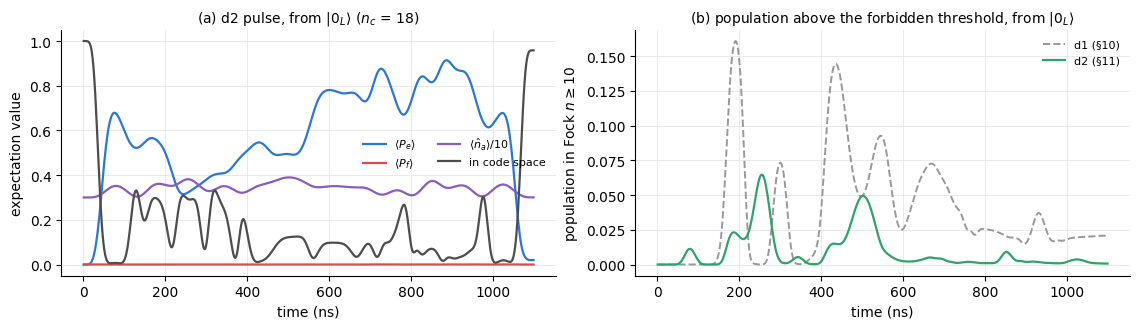

d1: time-averaged P_e + P_f = 0.604; max <n_a> = 4.76; max population in Fock n >= 10 = 0.161; time-summed = 20.9
d2: time-averaged P_e + P_f = 0.578; max <n_a> = 3.90; max population in Fock n >= 10 = 0.065; time-summed = 5.1


In [30]:
# Where the population goes: start in |0_L>, training model at n_c = 18, both runs
mdl18 = Model(N_REF, include_higher_order=True)
VL18 = embedded_basis(N_REF)
ops18 = operators(N_REF)
P_code18 = VL18 @ VL18.conj().T
n_fock18 = np.arange(mdl18.d) // 6
rho_in18 = np.outer(VL18[:, 0], VL18[:, 0].conj())[None]


def trajectory(u):
    _, tr = lnp.propagate(mdl18, u, rho_in18, DT_X2, store=True)
    return np.stack([r[0] for r in tr])                       # (N, d, d), state at the start of each step


traj2, traj1 = trajectory(u_X2), trajectory(u_X1)
expect = lambda op, tr: np.real(np.einsum("ij,kji->k", op, tr))         # noqa: E731
tail_of = lambda tr: np.array([np.real(np.diag(r))[n_fock18 >= 10].sum() for r in tr])   # noqa: E731
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
ax = axes[0]
pops = {r"$\langle P_e\rangle$": ops18["Pe"], r"$\langle P_f\rangle$": ops18["Pf"],
        r"$\langle \hat n_a\rangle / 10$": ops18["n_a"] / 10, "in code space": P_code18}
for (lab, op), col in zip(pops.items(), ("#2a78d6", "#e34948", "#8a5cc2", "0.3")):
    ax.plot(t_ns_X2, expect(op, traj2), lw=1.6, color=col, label=lab)
ax.set_xlabel("time (ns)"); ax.set_ylabel("expectation value")
ax.set_title(r"(a) d2 pulse, from $|0_L\rangle$ ($n_c$ = 18)", fontsize=10)
ax.legend(frameon=False, fontsize=8, ncol=2)
tidy(ax)
ax = axes[1]
tail1, tail2 = tail_of(traj1), tail_of(traj2)
ax.plot(t_ns_X2, tail1, lw=1.4, color="0.6", ls="--", label="d1 (§10)")
ax.plot(t_ns_X2, tail2, lw=1.6, color="#2fa36b", label="d2 (§11)")
ax.set_xlabel("time (ns)"); ax.set_ylabel(r"population in Fock $n \geq 10$")
ax.set_title(r"(b) population above the forbidden threshold, from $|0_L\rangle$", fontsize=10)
ax.legend(frameon=False, fontsize=8)
tidy(ax)
fig.tight_layout()
fig.savefig("figures/dgrape_X_d2_trajectory.png", dpi=150)
plt.show()
for name, tr, tl in [("d1", traj1, tail1), ("d2", traj2, tail2)]:
    exc = np.mean([np.real(np.trace((ops18["Pe"] + ops18["Pf"]) @ r)) for r in tr])
    print(f"{name}: time-averaged P_e + P_f = {exc:.3f}; max <n_a> = {expect(ops18['n_a'], tr).max():.2f}; "
          f"max population in Fock n >= 10 = {tl.max():.3f}; time-summed = {tl.sum():.1f}")


**Figure 9.** (a) Evolution of $|0_L\rangle$ under the d2 pulse, in the training model at $n_c = 18$; compare
Fig. 6. The transmon is still excited for most of the gate, and $\langle P_e\rangle$ rises to 0.9 in the second
half. 96 % of the population returns to the code space. (b) Population above the forbidden threshold, Fock
$n \ge 10$, for both pulses. Under the d2 pulse it peaks at 6.5 % instead of 16 %, and the time-summed
population (the $|0_L\rangle$ half of $C_{\rm forbid}$) falls fourfold, from 20.9 to 5.1. The d1 pulse also leaves
2 % of the population above Fock 10 at the end of the gate, which the d2 pulse does not.

## 11.2 Constraint report

In [31]:
c2 = info2["constraints"]
amp_max2 = info2["penalties"]["amp_max"]
checks_X2 = [
    ("peak |eps_C| (rad/μs)", info2["max_drive_modulus"]["cav"], f"<= {amp_max2}", info2["max_drive_modulus"]["cav"] <= amp_max2 * 1.001),
    ("peak |eps_T| (rad/μs)", info2["max_drive_modulus"]["tra"], f"<= {amp_max2}", info2["max_drive_modulus"]["tra"] <= amp_max2 * 1.001),
    ("max |x|, pre-image (rad/μs)", info2["max_abs_preimage"], f"< {info2['hard_amp_limit']}", info2["max_abs_preimage"] < info2["hard_amp_limit"]),
    ("fraction of x pinned at the box", info2["frac_preimage_pinned"], "= 0", info2["frac_preimage_pinned"] == 0),
    ("endpoint / peak amplitude", c2["endpoint_rel_to_peak"], "small (ramp)", True),
    ("out-of-band energy, cavity (fraction)", c2["out_of_band_cavity"], "small", True),
    ("out-of-band energy, transmon (fraction)", c2["out_of_band_transmon"], "small", True),
    ("held-out drift |F(20) - F(16)|", abs(F2_conv - F2_train), "<= 1e-4", abs(F2_conv - F2_train) <= 1e-4),
]
display(pd.DataFrame(checks_X2, columns=["quantity", "value", "requirement", "ok"])
        .style.format({"value": "{:.4g}"}).hide(axis="index").set_caption("Table 17. Is the d2 pulse trustworthy?"))


quantity,value,requirement,ok
peak |eps_C| (rad/μs),24.93,<= 25.0,True
peak |eps_T| (rad/μs),24.39,<= 25.0,True
"max |x|, pre-image (rad/μs)",25,< 25.0,False
fraction of x pinned at the box,0.01591,= 0,False
endpoint / peak amplitude,0.01305,small (ramp),True
"out-of-band energy, cavity (fraction)",0.000269,small,True
"out-of-band energy, transmon (fraction)",0.0007385,small,True
held-out drift |F(20) - F(16)|,8.465e-07,<= 1e-4,True


## 11.3 Verdict: the truncation problem is fixed; the gate is still clipped

**The training score is now the physical score.** $F_{\rm pro} = 0.95556$ at $n_c = 16$, 18 and 20. The three agree
to $10^{-6}$ (Table 16), so the gate's converged fidelity is **$F_{\rm pro} = 0.9556$ ($F_{\rm avg} = 0.9704$)**.
That is 4.0 percentage points above the §10 pulse's converged 0.9154, and its infidelity is 1.9× the 1.1 μs idle
floor, against 3.5× for §10. The reported training mean, 0.9564, is slightly optimistic: the $n_c = 12$ entry reads
$1.7\times10^{-3}$ high and $n_c = 14$ reads $8\times10^{-4}$ high. Of the three training truncations, only
$n_c = 16$ is converged.

**Error budget** (at $n_c = 18$; the rows overlap slightly and are not strictly additive):

| contribution | d2 (§11) | d1 (§10) | evidence |
|---|:-:|:-:|---|
| coherent control error | 0.9 % | 5.0 % | closed-system scores 0.991 and 0.950 (last two rows of Table 16) |
| dissipation | 3.6 % | 3.6 %* | 0.991 → 0.956. The idle floor is 2.4 %; the 1.2 % excess comes from the transmon sitting in $\lvert e\rangle$ (time-averaged $P_e + P_f$ = 0.58, Fig. 9a) |
| truncation artefact | $< 10^{-6}$ | 2.1 % | $n_c = 16, 18, 20$ agree |
| missing dephasing and heating | 1.1 % | 1.2 %* | all-channels score 0.945 |
| higher-order terms, if ignored | 0.5 % | 1.2 %* | the pulse scored without them, 0.950 |

\* §10 scored these at $n_c = 12$, inside its truncation artefact, so they are indicative only.

**What the changes bought.** The coherent error fell from 5.0 % to 0.9 %. The §10 pulse's apparent 2.8 % coherent
error (Table 13) was itself measured at the falsified $n_c = 12$. Dissipation stays at about 3.6 %. The gain therefore
comes entirely from removing the truncation exploit: once the optimizer could no longer use the wall at Fock 10–12,
it found a pulse that does the right thing in the full space. The forbidden-state cost $C_{\rm forbid}$ at
$n_c = 16$ fell from about 36 to 10.1.

**Constraints** (Table 17).
- **Still amplitude-limited.** $\lvert\epsilon_C\rvert$ peaks at 24.93 rad/μs and $\lvert\epsilon_T\rvert$ at
  24.39. 1.6 % of the pre-image is pinned at the box, against 2.0 % in §10. By this repository's rule, the pulse is
  clipped, not converged. Its held-out score is nevertheless stable, which is the check that rule asks for.
- **Ramp and bands are satisfied**: the endpoints are 1.3 % of peak, and the out-of-band energy is below
  $10^{-3}$ on both drives.
- **Leakage to $\lvert f\rangle$ remains negligible** (Fig. 9a).

**Status.** This is the first DGRAPE pulse whose score is trustworthy. At $F_{\rm pro} = 0.956$ it is not yet a
competitive gate. Dissipation dominates, and the next gains have to come from there:
1. **Shorten the time spent in $\lvert e\rangle$.** The 1.2 % excess decay comes from transmon excitation, and
   §10 traced the dephasing-and-heating gap to the same cause. Training with `--dephasing --heating` would make the
   optimizer pay for it.
2. **Scan $T_g$ and the amplitude cap.** The box still binds at 1.1 μs, so a shorter gate needs a looser
   `hard_amp_limit`. The idle floor sets the price of a longer one, about 2.2 % per μs.
3. **Re-weigh $\lambda_{\rm forbid}$.** At 14 % of the final cost it trades directly against fidelity. Now that
   $n_c = 16$ is converged, a smaller weight might be affordable, as long as the held-out check still passes.
4. **Truncations.** $n_c = 12$ is not converged for this pulse. $[14, 16]$ or $[16, 18]$, with `n_r = 1` to pay for
   it, would make the training mean the physical score.

# 12. Open decisions and next steps

The machinery is complete and validated. These choices still depend on the chip and on what §10 and §11 showed.

**Table 18.** Open decisions.

| decision | why it matters | status |
|---|---|---|
| gate duration $T_g$ | dissipation now competes with speed: the idle floor is 2.2 % per μs (Fig. 1), but a shorter gate needs larger drives and more transmon excitation | §10 and §11 use 1.1 μs. **Scan** $T_g$ (e.g. 0.6–1.6 μs) per gate and plot the trained $1-F_{\rm pro}$ against the idle floor |
| truncation list | cost $\propto d^3$. The code needs only Fock 5, but a trained pulse may climb far higher | **$[10, 12]$ failed** (§10.3): the X pulse reached Fock 10+ and lost 2.1 % between $n_c = 12$ and the converged $n_c \ge 16$. **Default now $[12, 14, 16]$**, every entry above the forbidden threshold. **Validated for X** (§11): held-out $n_c = 18, 20$ match $n_c = 16$ to $10^{-6}$, but $n_c = 12$ reads $1.7\times10^{-3}$ high. Next: $[14, 16]$ or $[16, 18]$, with `n_r=1` (needs an `--n-r` option) to pay for it |
| discrepancy weight $\lambda_{\rm disc}$ | 0.5 gave a penalty of $\sim 2\times10^{-4}$, too weak to stop truncation exploitation | **forbidden-state penalty added** (§7.1): $\lambda_{\rm forbid} = 10^{-3}$ on Fock $\ge 10$. The §10 X pulse scores $C = 36$ there, a cost of 0.036, against $2\times10^{-4}$ from Eq. 24. At this weight the §11 run reached $C = 10$ and converged in truncation; the term was 14 % of its final cost. The weight itself is unvalidated |
| higher-order terms (§2.4) | 0.7 % idle error at 1.1 μs | **resolved: on for training** (`--higher-order`) |
| dephasing and heating | decay only by default; the X pulse keeps the transmon excited, and the extra channels cost 1.2 % (§10) and 1.1 % (§11) | **train with them** (`--dephasing --heating`) |
| filter bands, ramp | Heeres values; $\pm33$ MHz already excludes the $e\to f$ line | keep; revisit if a gate needs more bandwidth |
| $u_{\max}$, `hard_amp_limit` | no Shirol drive limit is published | 25 / 25 **binds**: the X pulses pinned 2 % (§10) and 1.6 % (§11) of the box, with $\lvert\epsilon_C\rvert$ = 24.8 and 24.9. Relax it, or lengthen $T_g$ |
| $\lambda_{\text{deriv}}, \lambda_{\text{amp}}$ | tuned on the Heeres chip (`analysis/penalty_sweep.py`); $\lambda_{\text{deriv}}$ was 18 % and 19 % of the two X runs' final costs | unvalidated here; a reduced sweep once a duration is fixed |
| run logic | §10: 1000 iterations did not converge, 19.5 h, no checkpoint. §11: 10.3 h on 9 jobs, plateaued after about 500 iterations | **parallel truncations done** (`--n-jobs`, default 3, joblib; 2.0× per evaluation on $[12, 14, 16]$, §9). Periodic checkpoints still to add |
| closed vs open objective | the benefit of exact Open-GRAPE should be measured, not assumed | train the same gate with `rate_scale=0` and with dissipation; score both under the full Lindbladian |

Training command at the new defaults ($n_c \in \{12, 14, 16\}$ as 3 parallel jobs, $\lambda_{\rm forbid} = 10^{-3}$;
the duration and $\Delta t$ are required). §10 ran it with `--n-c 10 12` and no forbidden-state term; §11 ran it with `--n-jobs 9`:

```bash
python3 DGRAPE/train.py --gate X --duration-us 1.1 --dt 0.002 --max-iter 1000 --higher-order --tag X_open_d2
```

Pulses go to `pulses/dgrape/`, never `pulses/`. Every `analysis/` and `validation/` script finds pulses in
`pulses/` by name and assumes the Heeres cat code, so a kitten-code pulse there would be silently mis-scored.